#  THIS CODE DOCUMENT IS FOR DATA VISUALIZATION " 
Machine Learning in Football prediction for the Begian Jupiler League

In [6]:
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries

# Preprocessing and Feature Selection
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# Model Selection and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Verify that all packages are imported correctly
print("All packages imported successfully.")


All packages imported successfully.


In [7]:
import sys
import pandas
import numpy
import sklearn
import xgboost
import seaborn

print("Python version:", sys.version)
print("pandas version:", pandas.__version__)
print("numpy version:", numpy.__version__)
print("scikit-learn version:", sklearn.__version__)
print("xgboost version:", xgboost.__version__)
print("seaborn version:", seaborn.__version__)


Python version: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
pandas version: 2.1.4
numpy version: 1.26.3
scikit-learn version: 1.5.1
xgboost version: 2.1.1
seaborn version: 0.13.2


In [8]:

# Reading the datasets (assuming they are CSV files)

B1920 = pd.read_csv('B1920.csv')
B2021 = pd.read_csv('B2021.csv')
B2122 = pd.read_csv('B2122.csv')
B2223 = pd.read_csv('B2223.csv')
B2324 = pd.read_csv('B2324.csv')



In [9]:

print(f'2019/2020 season shape: {B1920.shape}')
print(f'2020/2021 season shape: {B2021.shape}')
print(f'2021/2022 season shape: {B2122.shape}')
print(f'2022/2023 season shape: {B2223.shape}')
print(f'2023/2024 season shape: {B2324.shape}')

2019/2020 season shape: (232, 105)
2020/2021 season shape: (306, 105)
2021/2022 season shape: (306, 106)
2022/2023 season shape: (306, 105)
2023/2024 season shape: (312, 105)


the data retrived from football.co.uk shows dissimilarities  accross the different years considered on the total number of matches played. 
-2018/2019 season had 240 games played 
-2019/2020 season had  232 games played
-2020/2021, 2021/2022, 2022/2023 all had 306 games played.
-2023/2024 season had 312 games played

**The differene in total number of games will be invegated and if need be will be adjusted.**

# Merging  datasets
 the 6 season datasets is combined into on main dataset  for further analyis and exploration.

In [10]:
# List of DataFrames
dfs = [ B1920, B2021, B2122, B2223, B2324]

# Concatenate the DataFrames vertically (one below the other)
merged_data = pd.concat(dfs, ignore_index=True)


# Display the merged dataset
merged_data.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Unnamed: 105
0,B1,26/07/2019,19:30,Genk,Kortrijk,2,1,H,0.0,1.0,...,-1.25,1.98,1.88,2.01,1.88,2.05,1.96,1.96,1.87,NaN
1,B1,27/07/2019,17:00,Cercle Brugge,Standard,0,2,A,0.0,0.0,...,0.50,1.88,1.98,1.91,1.99,1.95,2.02,1.89,1.94,NaN
2,B1,27/07/2019,19:00,St Truiden,Mouscron,0,1,A,0.0,1.0,...,-0.25,1.83,2.02,1.87,2.03,1.88,2.07,1.83,2.02,NaN
3,B1,27/07/2019,19:00,Waregem,Mechelen,0,2,A,0.0,1.0,...,0.25,1.72,2.07,1.75,2.17,1.80,2.28,1.72,2.15,NaN
4,B1,27/07/2019,19:30,Waasland-Beveren,Club Brugge,1,3,A,1.0,1.0,...,1.50,2.20,1.70,2.19,1.74,2.25,1.83,2.11,1.74,NaN


Removing irrelevant columns from the dataset

In [11]:



# Find the index position of the 'B365A' column
ar_index = merged_data.columns.get_loc('B365A')

# Select all columns up to and including 'AR'
merged_data = merged_data.iloc[:, :ar_index + 1]
# Drop the specified columns
merged_data.drop(columns=['HTHG', 'HTAG', 'HTR'], inplace=True)

merged_data.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR',
       'AR', 'B365H', 'B365D', 'B365A'],
      dtype='object')

In [12]:
# Convert 'Date' column to datetime dtype
merged_data['Date'] = pd.to_datetime(
    merged_data['Date'], dayfirst=True, errors='coerce'
)

# Convert 'Time' column to datetime and extract the hour
merged_data['Hour'] = pd.to_datetime(
    merged_data['Time'], format='%H:%M', errors='coerce'
).dt.hour


# Step 3: Verify the data types

merged_data.dtypes

Div                 object
Date        datetime64[ns]
Time                object
HomeTeam            object
AwayTeam            object
FTHG                 int64
FTAG                 int64
FTR                 object
HS                 float64
AS                 float64
HST                float64
AST                float64
HF                 float64
AF                 float64
HC                 float64
AC                 float64
HY                 float64
AY                 float64
HR                 float64
AR                 float64
B365H              float64
B365D              float64
B365A              float64
Hour                 int32
dtype: object

In [13]:
merged_data.shape

(1462, 24)

#  Data Exploration

1. Introduction
In this notebook, we will perform an exploratory data analysis (EDA) on the Belgian Pro League football dataset, which contains data from five different seasons. Our target variable is the Full-Time Result (FTR), where:

H: Home team win
D: Draw
A: Away team win
Our goal is to understand the data better and prepare it for machine learning modeling.

 ## Statistical Summary

In [14]:
# Get statistical summary for numerical columns
merged_data.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,1462,2022-01-18 05:35:52.120382976,2019-07-26 00:00:00,2020-12-07 06:00:00,2022-01-16 00:00:00,2023-03-08 18:00:00,2024-06-02 00:00:00,NaN
FTHG,1462.0,1.594391,0.0,1.0,1.0,2.0,7.0,1.31502
FTAG,1462.0,1.331053,0.0,0.0,1.0,2.0,7.0,1.183901
HS,1457.0,13.171585,1.0,10.0,12.0,17.0,33.0,5.226274
AS,1457.0,11.108442,1.0,8.0,11.0,14.0,29.0,4.634058
HST,1457.0,4.902539,0.0,3.0,5.0,6.0,16.0,2.496723
AST,1457.0,4.170899,0.0,2.0,4.0,6.0,22.0,2.347322
HF,1457.0,11.700069,1.0,9.0,11.0,14.0,25.0,3.846106
AF,1457.0,12.494166,3.0,10.0,12.0,15.0,26.0,3.919538
HC,1457.0,5.459849,0.0,4.0,5.0,7.0,21.0,2.812587


# Checking for Missing Values

In [15]:
# Check for missing values
missing_values = merged_data.isnull().sum()
missing_values[missing_values > 0]


HS       5
AS       5
HST      5
AST      5
HF       5
AF       5
HC       5
AC       5
HY       4
AY       4
HR       4
AR       4
B365H    1
B365D    1
B365A    1
dtype: int64

Handling Missing Values:

If there are missing values, we'll need to decide how to handle them.

In [16]:
# Percentage of missing values
missing_percent = (merged_data.isnull().sum() / merged_data.shape[0]) * 100
missing_percent[missing_percent > 0]


HS       0.341997
AS       0.341997
HST      0.341997
AST      0.341997
HF       0.341997
AF       0.341997
HC       0.341997
AC       0.341997
HY       0.273598
AY       0.273598
HR       0.273598
AR       0.273598
B365H    0.068399
B365D    0.068399
B365A    0.068399
dtype: float64

Strategy:

If missing values are few, we can drop those rows.

If missing values are significant, we may need to impute them.  that get the results from online sources

# 4. Data Preprocessing
4.1. Converting 'Date' to Datetime and Extracting 'Hour'

In [17]:
# Convert 'Date' to datetime
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')

# Extract 'Hour' from 'Time' and convert to integer
merged_data['Hour'] = pd.to_datetime(merged_data['Time'], format='%H:%M', errors='coerce').dt.hour

# Drop 'Time' column
merged_data.drop(columns=['Time'], inplace=True)


### Encoding the Target Variable 'FTR'

In [18]:
# Check unique values in 'FTR'
merged_data['FTR'].unique()


array(['H', 'A', 'D'], dtype=object)

In [19]:
# Map 'FTR' to numerical values
ftr_mapping = {'H': 1, 'D': 0, 'A': 2}
merged_data['FTR_numeric'] = merged_data['FTR'].map(ftr_mapping)


Extracting Additional Date Features

In [20]:
# Extract year, month, day, and day of the week
merged_data['Year'] = merged_data['Date'].dt.year
merged_data['Month'] = merged_data['Date'].dt.month
merged_data['Day'] = merged_data['Date'].dt.day
merged_data['DayOfWeek'] = merged_data['Date'].dt.day_name()


## 4.5. Handling Categorical Variables

In [21]:
# List of categorical variables
categorical_vars = ['Div', 'HomeTeam', 'AwayTeam', 'DayOfWeek']

# Display unique values for each categorical variable
for var in categorical_vars:
    print(f"\nUnique values in {var}: {merged_data[var].nunique()}")



Unique values in Div: 1

Unique values in HomeTeam: 22

Unique values in AwayTeam: 22

Unique values in DayOfWeek: 7


Encoding Categorical Variables:

Div: If there is only one division, encoding is not necessary.
HomeTeam and AwayTeam: We can use Label Encoding or One-Hot Encoding.
For teams, since there may be many unique values, Label Encoding is preferable.

In [22]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoders
le_home = LabelEncoder()
le_away = LabelEncoder()

# Encode 'HomeTeam' and 'AwayTeam'
merged_data['HomeTeam_enc'] = le_home.fit_transform(merged_data['HomeTeam'])
merged_data['AwayTeam_enc'] = le_away.fit_transform(merged_data['AwayTeam'])


In [23]:
merged_data.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,B365D,B365A,Hour,FTR_numeric,Year,Month,Day,DayOfWeek,HomeTeam_enc,AwayTeam_enc
0,B1,2019-07-26,Genk,Kortrijk,2,1,H,10.0,8.0,2.0,...,4.75,8.50,19,1,2019,7,26,Friday,7,9
1,B1,2019-07-27,Cercle Brugge,Standard,0,2,A,13.0,14.0,5.0,...,3.75,1.85,17,2,2019,7,27,Saturday,3,18
2,B1,2019-07-27,St Truiden,Mouscron,0,1,A,10.0,10.0,4.0,...,3.75,3.75,19,2,2019,7,27,Saturday,16,11
3,B1,2019-07-27,Waregem,Mechelen,0,2,A,7.0,10.0,2.0,...,3.60,3.10,19,2,2019,7,27,Saturday,20,10
4,B1,2019-07-27,Waasland-Beveren,Club Brugge,1,3,A,7.0,25.0,2.0,...,4.00,1.50,19,2,2019,7,27,Saturday,19,5


In [24]:
merged_data.columns

Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS',
       'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
       'B365H', 'B365D', 'B365A', 'Hour', 'FTR_numeric', 'Year', 'Month',
       'Day', 'DayOfWeek', 'HomeTeam_enc', 'AwayTeam_enc'],
      dtype='object')

Encode 'DayOfWeek' using One-Hot Encoding.

In [25]:
# 4.4. Handling Categorical Variables

# Extract day of the week
merged_data['DayOfWeek'] = merged_data['Date'].dt.day_name()

# Map 'DayOfWeek' to numerical values
day_mapping = {
    'Sunday': 1,
    'Monday': 2,
    'Tuesday': 3,
    'Wednesday': 4,
    'Thursday': 5,
    'Friday': 6,
    'Saturday': 7
}

merged_data['DayOfWeek_Num'] = merged_data['DayOfWeek'].map(day_mapping)

# Drop the original 'DayOfWeek' column
merged_data.drop(columns=['DayOfWeek'], inplace=True)


# Correlation Analysis

In [26]:
# Drop the 'Div' column
merged_data_numeric = merged_data.drop('Div', axis=1)



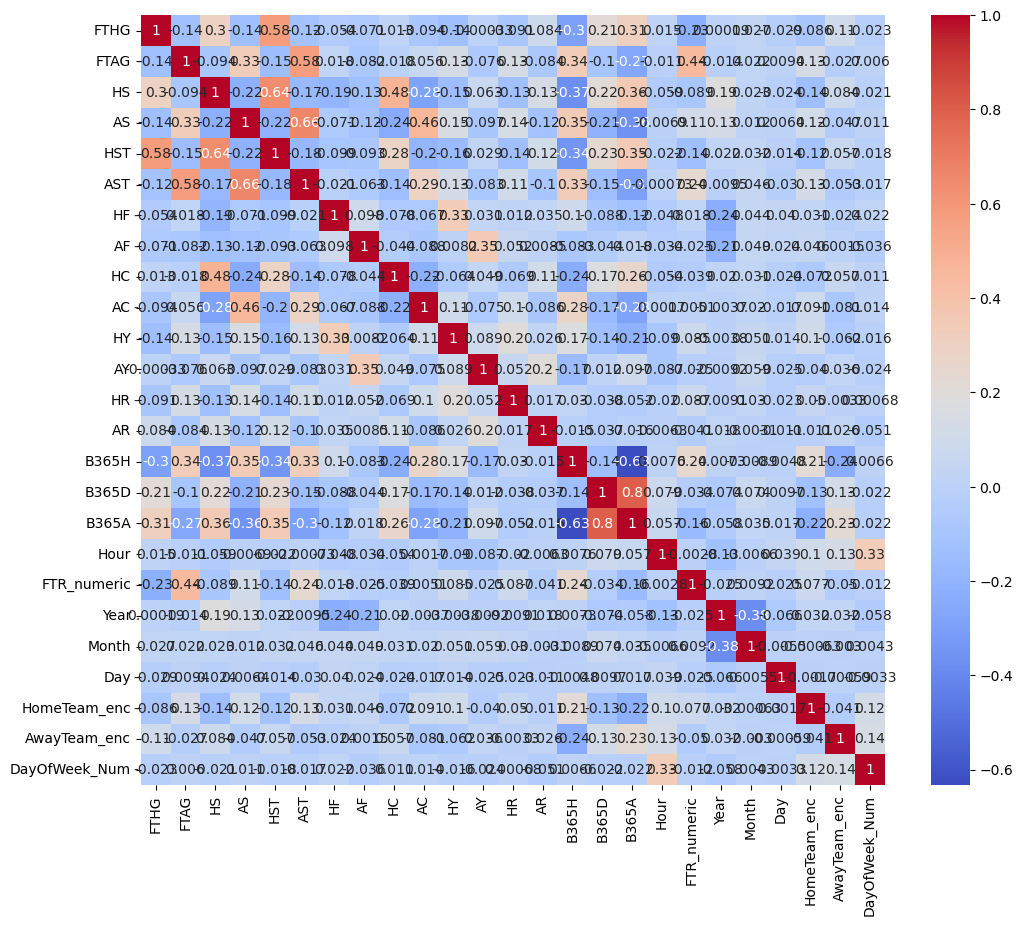

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only numerical columns
merged_data_numeric = merged_data.select_dtypes(include=[np.number])

# Now you can compute the correlation matrix on the numerical data
corr_matrix = merged_data_numeric.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


 ## Distribution of Numerical Variables

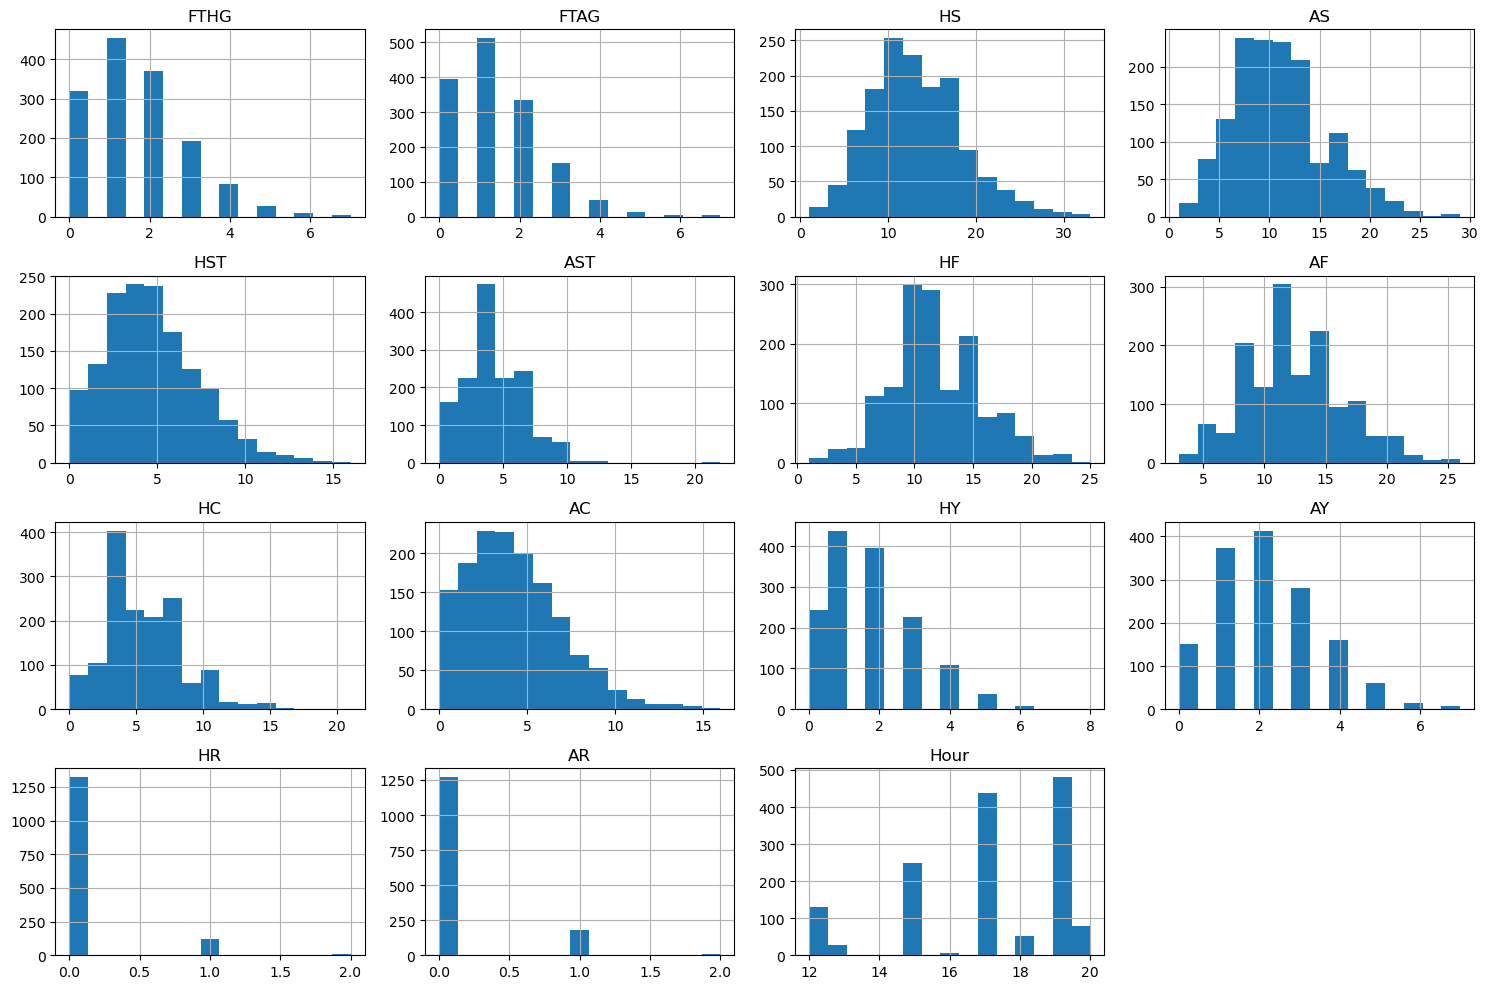

In [28]:
# List of numerical variables
numerical_vars = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'Hour']

# Histograms
merged_data[numerical_vars].hist(figsize=(15, 10), bins=15)
plt.tight_layout()
plt.show()


4.9. Box Plots for Outlier Detection

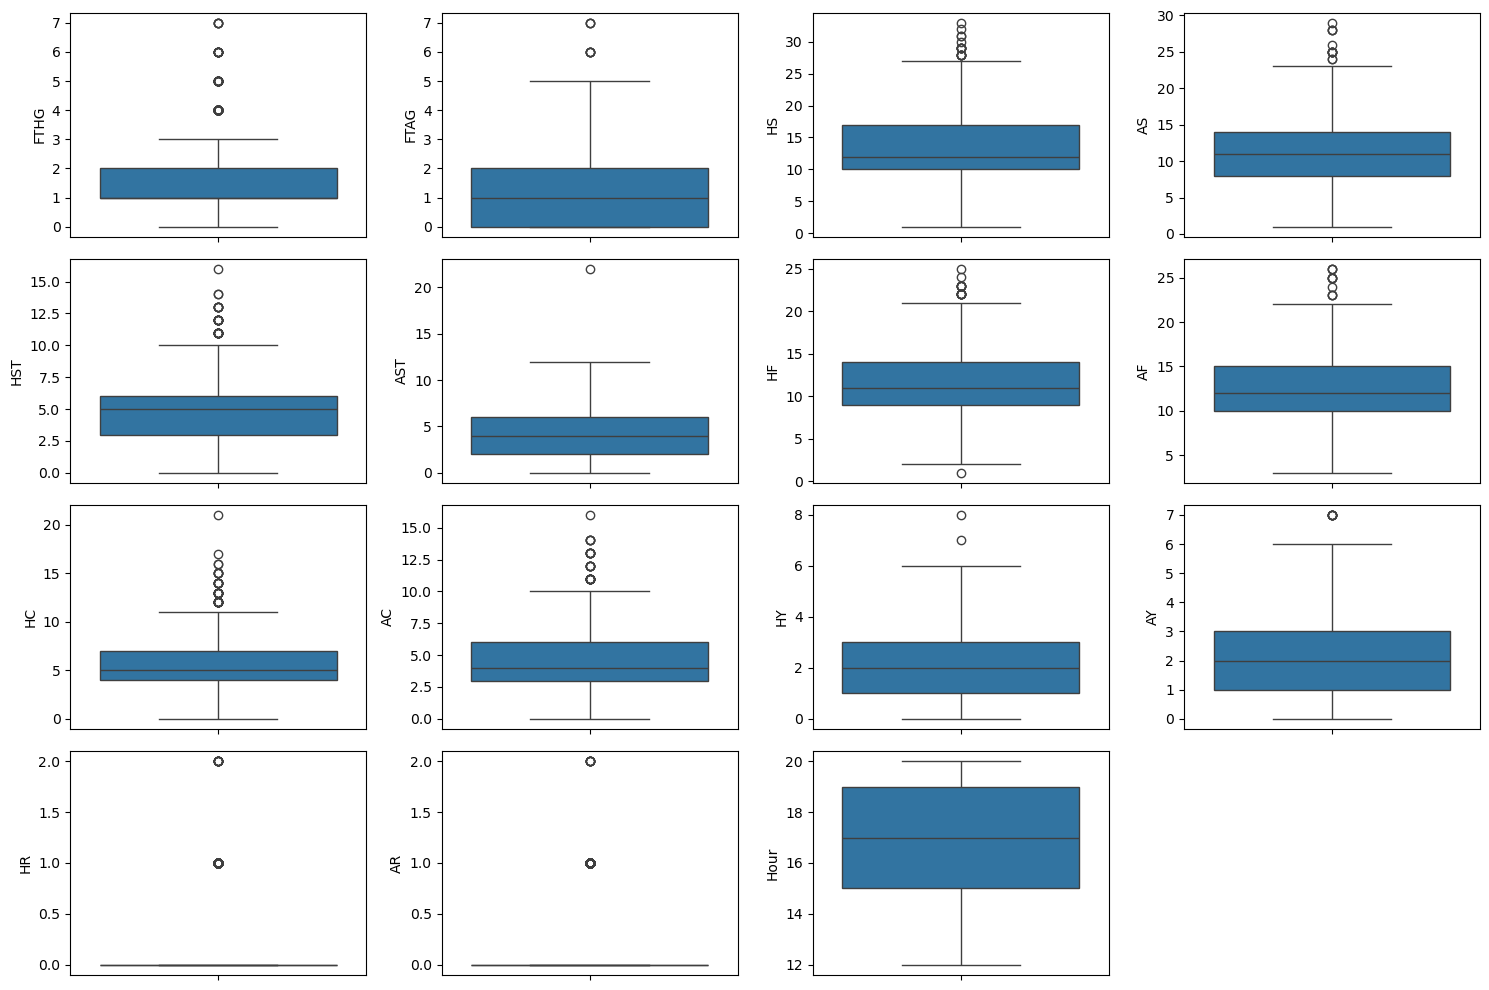

In [29]:
# Box plots for numerical variables
plt.figure(figsize=(15, 10))
for i, var in enumerate(numerical_vars):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=merged_data[var])
    plt.tight_layout()


5. Exploratory Data Analysis (EDA)

5.1. Target Variable Distribution

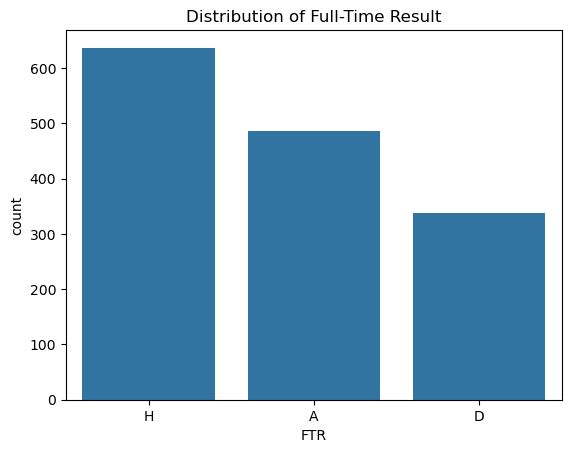

In [30]:
# Distribution of 'FTR'
sns.countplot(x='FTR', data=merged_data)
plt.title('Distribution of Full-Time Result')
plt.show()


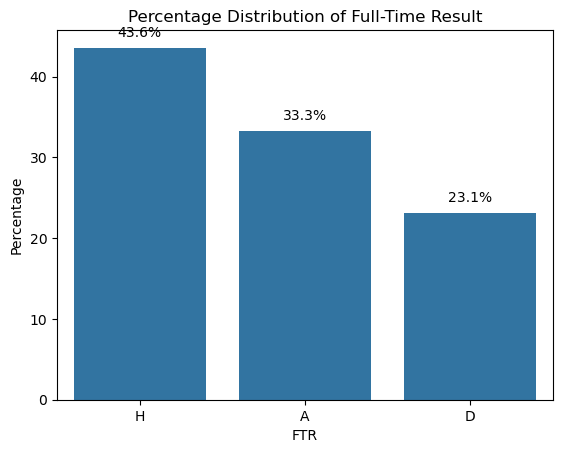

In [64]:


# Calculate the percentage distribution
ftr_percentage = merged_data['FTR'].value_counts(normalize=True) * 100

# Create a barplot with percentage values
sns.barplot(x=ftr_percentage.index, y=ftr_percentage.values)

# Display percentage on top of the bars
for i, value in enumerate(ftr_percentage.values):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', va='bottom')

plt.title('Percentage Distribution of Full-Time Result')
plt.ylabel('Percentage')
plt.show()


In [31]:
# Calculate the percentage of each category in 'FTR'
ftr_percentages = merged_data['FTR'].value_counts(normalize=True) * 100

# Display the percentages
print("Percentage of each Full-Time Result category:")
print(ftr_percentages)


Percentage of each Full-Time Result category:
FTR
H    43.570451
A    33.310534
D    23.119015
Name: proportion, dtype: float64


Observation:

Check if the classes are balanced.

5.2. Home vs Away Statistics

In [32]:
# Average goals scored by Home and Away teams
avg_goals = merged_data.groupby('FTR')[['FTHG', 'FTAG']].mean().reset_index()
avg_goals


,FTR,FTHG,FTAG
0,A,0.616016,2.379877
1,D,1.159763,1.159763
2,H,2.572998,0.620094


## 5.3. Impact of 'Hour' on Match Outcome

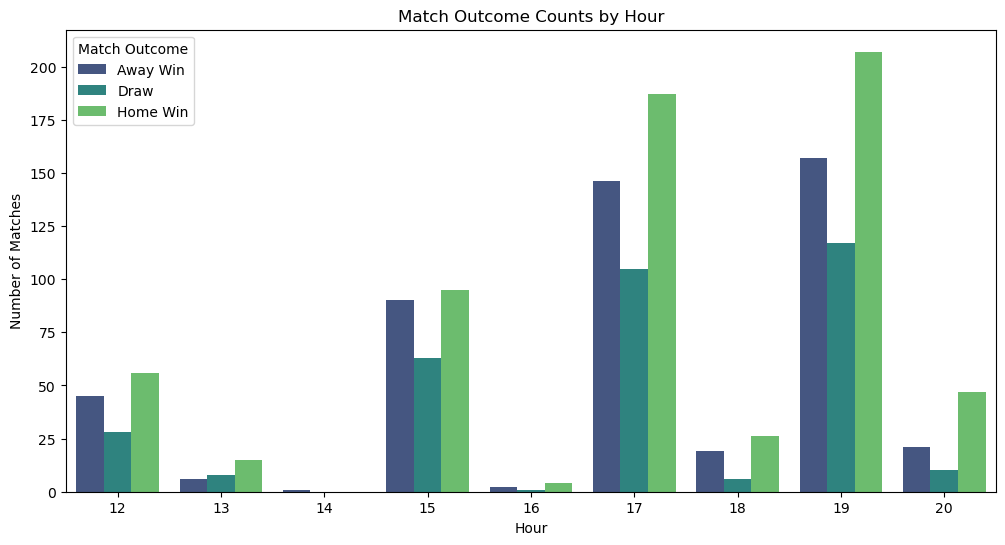

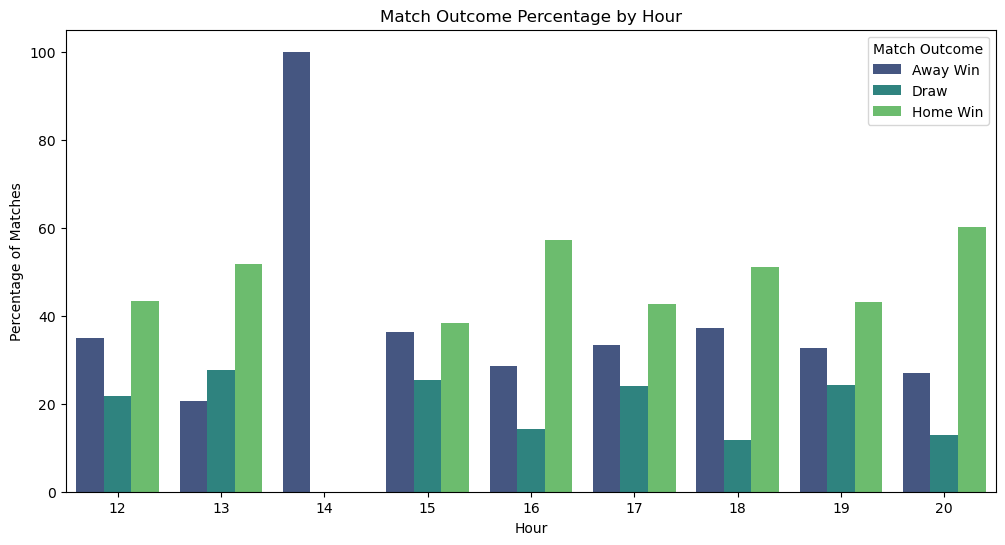

In [33]:
# Step 1: Map 'FTR' to numerical values using 2 for 'Away Win'
ftr_mapping = {'H': 1, 'D': 0, 'A': 2}
merged_data['FTR_numeric'] = merged_data['FTR'].map(ftr_mapping)

# Step 2: Map 'FTR_numeric' back to labels and convert to categorical
ftr_numeric_labels = {1: 'Home Win', 0: 'Draw', 2: 'Away Win'}
merged_data['FTR_category'] = merged_data['FTR_numeric'].map(ftr_numeric_labels)
merged_data['FTR_category'] = merged_data['FTR_category'].astype('category')

# Step 3: Group data by 'Hour' and 'FTR_category' and calculate counts
hourly_outcome = merged_data.groupby(['Hour', 'FTR_category']).size().reset_index(name='Count')

# Optional: Calculate percentages
total_matches_per_hour = merged_data.groupby('Hour').size().reset_index(name='Total')
hourly_outcome = hourly_outcome.merge(total_matches_per_hour, on='Hour')
hourly_outcome['Percentage'] = (hourly_outcome['Count'] / hourly_outcome['Total']) * 100

# Step 4.1: Plotting Counts
plt.figure(figsize=(12,6))
sns.barplot(x='Hour', y='Count', hue='FTR_category', data=hourly_outcome, palette='viridis')
plt.title('Match Outcome Counts by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Matches')
plt.legend(title='Match Outcome')
plt.show()

# Step 4.2: Plotting Percentages (Optional)
plt.figure(figsize=(12,6))
sns.barplot(x='Hour', y='Percentage', hue='FTR_category', data=hourly_outcome, palette='viridis')
plt.title('Match Outcome Percentage by Hour')
plt.xlabel('Hour')
plt.ylabel('Percentage of Matches')
plt.legend(title='Match Outcome')
plt.show()


##  Make the plot above per outcome( different colour bars per outcome)

## 5.4. Day of the Week Analysis

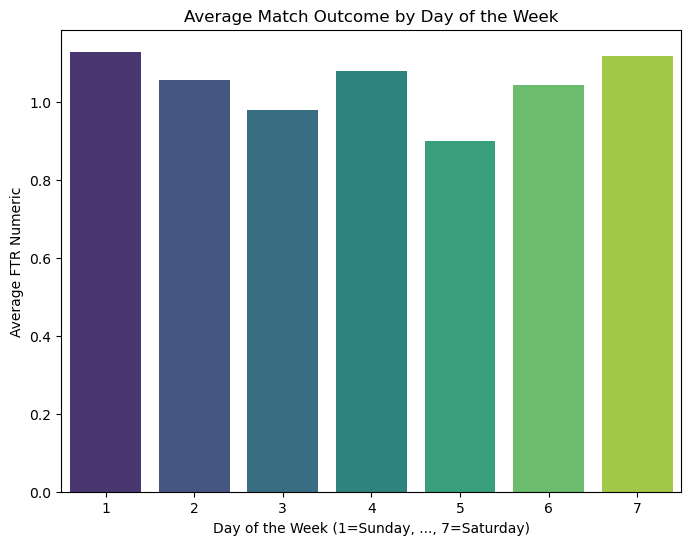

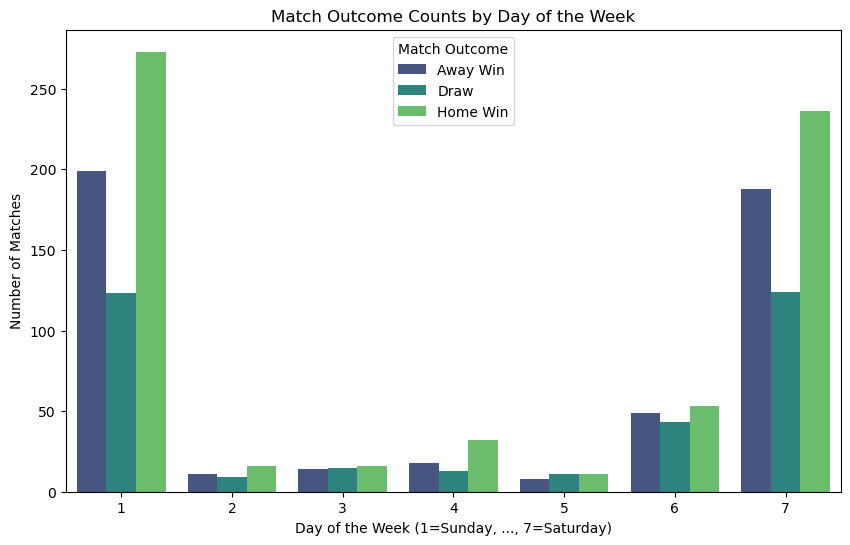

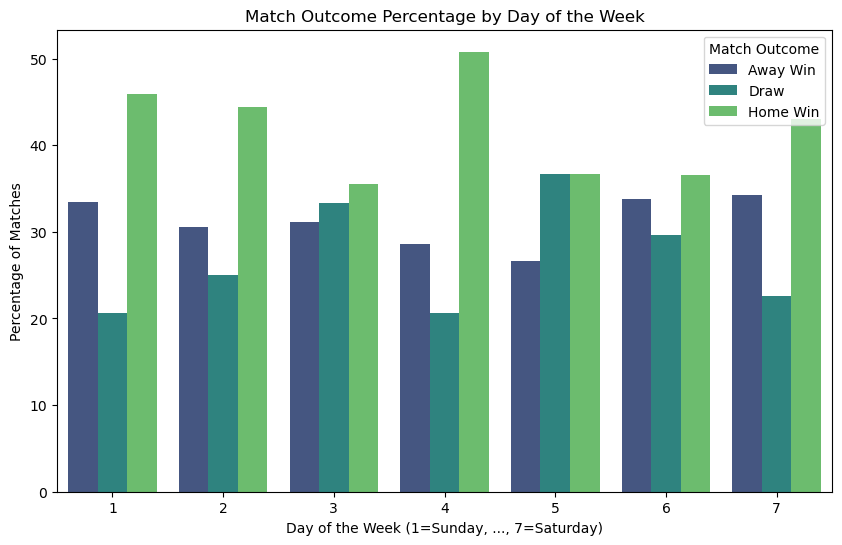

In [34]:
# Map 'FTR' to numerical values using 2 for 'Away Win' (if not already done)
ftr_mapping = {'H': 1, 'D': 0, 'A': 2}
merged_data['FTR_numeric'] = merged_data['FTR'].map(ftr_mapping)

# Map 'FTR_numeric' back to labels
ftr_numeric_labels = {1: 'Home Win', 0: 'Draw', 2: 'Away Win'}
merged_data['FTR_category'] = merged_data['FTR_numeric'].map(ftr_numeric_labels)
merged_data['FTR_category'] = merged_data['FTR_category'].astype('category')

# 1. Plotting the Average 'FTR_numeric' by 'DayOfWeek_Num'

# Calculate the average 'FTR_numeric' by 'DayOfWeek_Num'
day_outcome = merged_data.groupby('DayOfWeek_Num')['FTR_numeric'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(8,6))
sns.barplot(x='DayOfWeek_Num', y='FTR_numeric', data=day_outcome, palette='viridis')

# Add titles and labels
plt.title('Average Match Outcome by Day of the Week')
plt.xlabel('Day of the Week (1=Sunday, ..., 7=Saturday)')
plt.ylabel('Average FTR Numeric')

# Show the plot
plt.show()

# 2. Plotting the Distribution of Match Outcomes by 'DayOfWeek_Num'

# Group by 'DayOfWeek_Num' and 'FTR_category' and count
day_outcome_counts = merged_data.groupby(['DayOfWeek_Num', 'FTR_category']).size().reset_index(name='Count')

# Calculate total matches per day
total_matches_per_day = merged_data.groupby('DayOfWeek_Num').size().reset_index(name='Total')

# Merge total matches with day_outcome_counts
day_outcome_counts = day_outcome_counts.merge(total_matches_per_day, on='DayOfWeek_Num')

# Calculate percentage
day_outcome_counts['Percentage'] = (day_outcome_counts['Count'] / day_outcome_counts['Total']) * 100

# Plotting counts
plt.figure(figsize=(10,6))
sns.barplot(x='DayOfWeek_Num', y='Count', hue='FTR_category', data=day_outcome_counts, palette='viridis')
plt.title('Match Outcome Counts by Day of the Week')
plt.xlabel('Day of the Week (1=Sunday, ..., 7=Saturday)')
plt.ylabel('Number of Matches')
plt.legend(title='Match Outcome')
plt.show()

# Plotting percentages
plt.figure(figsize=(10,6))
sns.barplot(x='DayOfWeek_Num', y='Percentage', hue='FTR_category', data=day_outcome_counts, palette='viridis')
plt.title('Match Outcome Percentage by Day of the Week')
plt.xlabel('Day of the Week (1=Sunday, ..., 7=Saturday)')
plt.ylabel('Percentage of Matches')
plt.legend(title='Match Outcome')
plt.show()


## 5.5. Top Teams Analysis

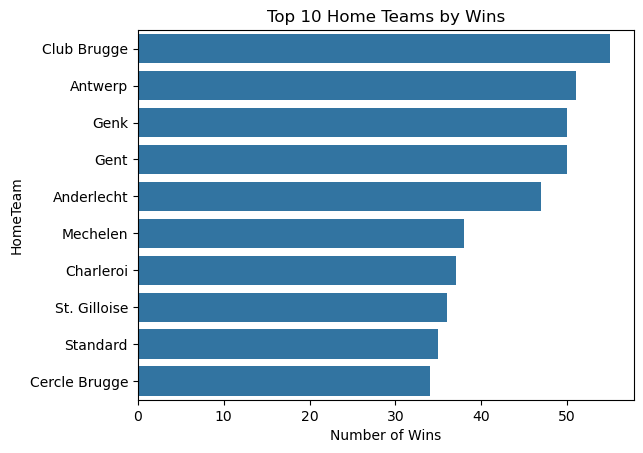

In [35]:
# Total wins by Home Team
home_wins = merged_data[merged_data['FTR'] == 'H']['HomeTeam'].value_counts().head(10)
sns.barplot(x=home_wins.values, y=home_wins.index)
plt.title('Top 10 Home Teams by Wins')
plt.xlabel('Number of Wins')
plt.show()


In [36]:





# Ensure 'Date' is in datetime format and extract 'Year' if not already done
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)


In [37]:
# Overall percentage of match outcomes by HomeTeam
overall_crosstab = pd.crosstab(
    merged_data['HomeTeam'], 
    merged_data['Result'], 
    normalize='index'
) * 100

# Reset index to convert it back to a DataFrame
overall_crosstab = overall_crosstab.reset_index()


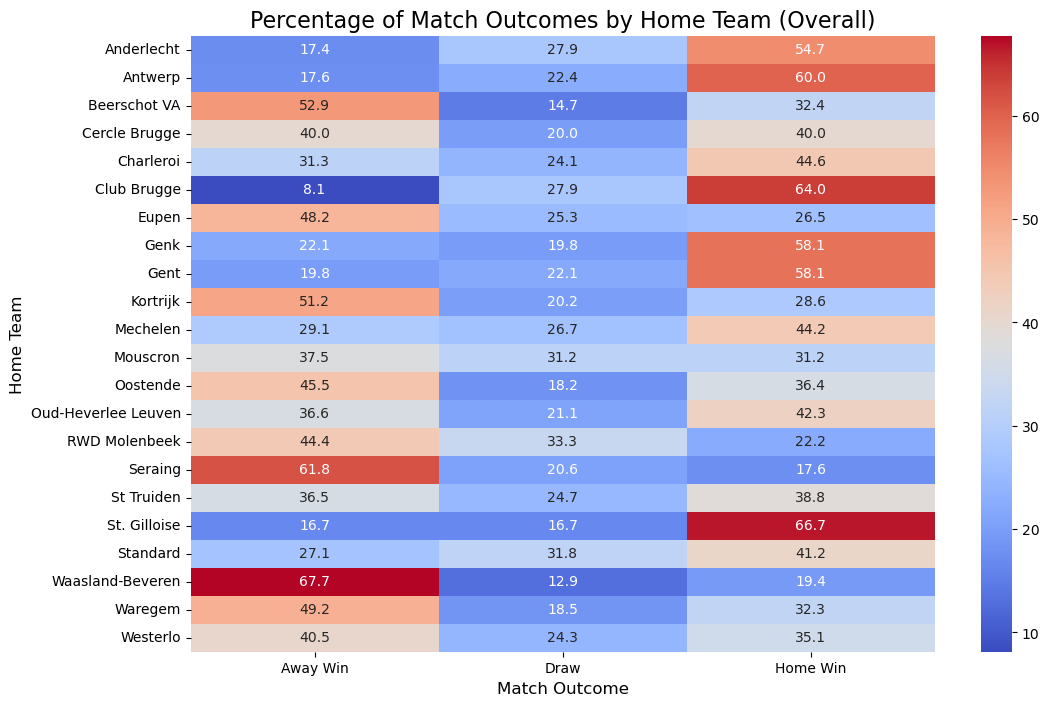

In [38]:
# Heatmap for overall percentages
plt.figure(figsize=(12, 8))
sns.heatmap(
    overall_crosstab.set_index('HomeTeam'), 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm'
)
plt.title('Percentage of Match Outcomes by Home Team (Overall)', fontsize=16)
plt.xlabel('Match Outcome', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


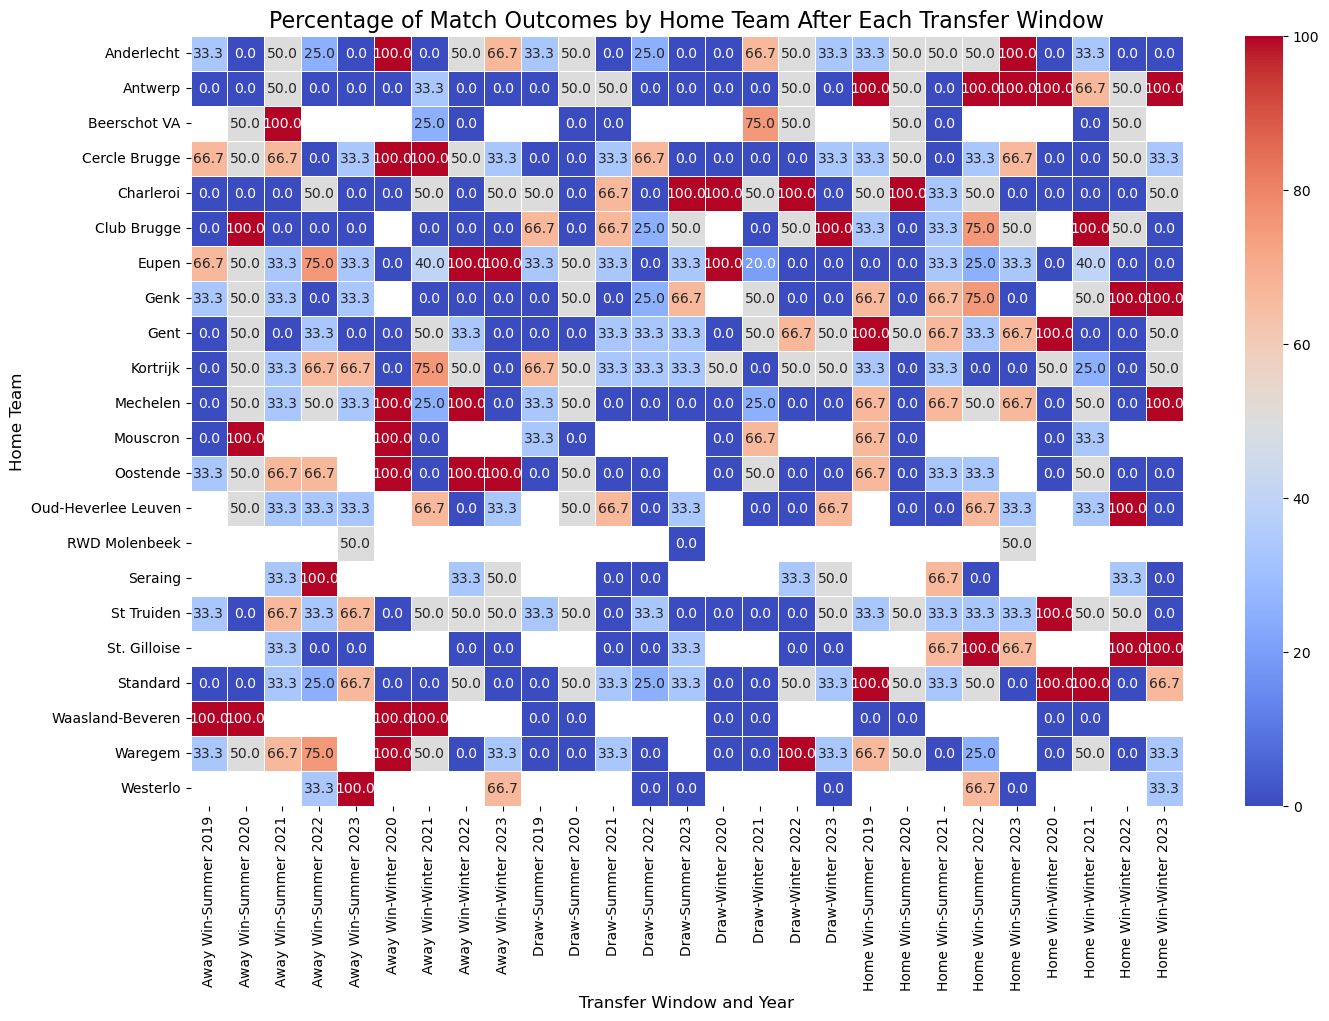

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' is in datetime format and extract 'Year' if not already done
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the transfer window periods with year
transfer_windows = [
    ('Summer', pd.to_datetime(f'{year}-06-01'), pd.to_datetime(f'{year}-09-06')) for year in range(2019, 2024)
] + [
    ('Winter', pd.to_datetime(f'{year}-01-01'), pd.to_datetime(f'{year}-01-31')) for year in range(2019, 2024)
]

# Loop through each transfer window period and calculate the match outcomes
results_by_period = []

for window_name, window_start, window_end in transfer_windows:
    # Filter the data by the current transfer window period
    period_data = merged_data[(merged_data['Date'] >= window_start) & (merged_data['Date'] <= window_end)]
    
    # Calculate the percentage of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result'], 
        normalize='index'
    ) * 100

    # Reset the index and add the period name with the year
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Transfer Window'] = f'{window_name} {window_start.year}'  # Include the year in the label
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win', 'Draw', 'Away Win'], 
    index='HomeTeam', 
    columns='Transfer Window', 
    aggfunc='mean'
)

# Plotting the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Percentage of Match Outcomes by Home Team After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


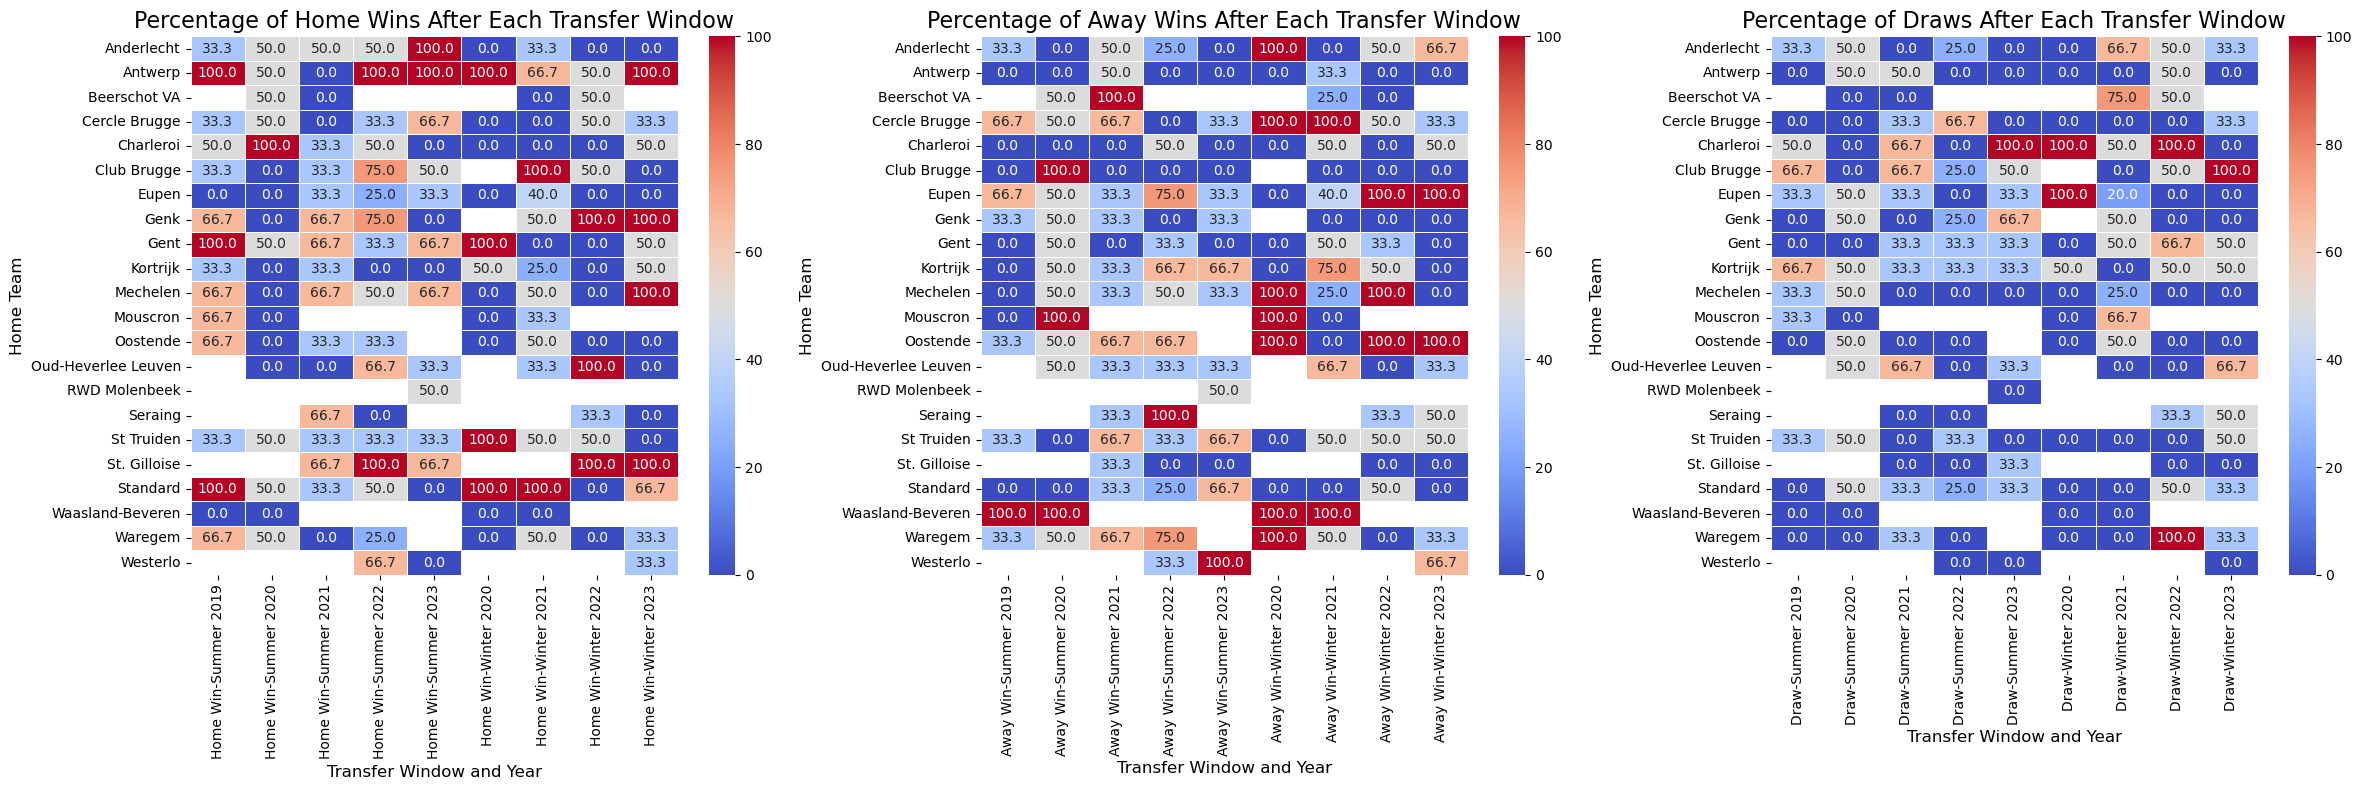

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' is in datetime format and extract 'Year' if not already done
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the transfer window periods with year
transfer_windows = [
    ('Summer', pd.to_datetime(f'{year}-06-01'), pd.to_datetime(f'{year}-09-06')) for year in range(2019, 2024)
] + [
    ('Winter', pd.to_datetime(f'{year}-01-01'), pd.to_datetime(f'{year}-01-31')) for year in range(2019, 2024)
]

# Loop through each transfer window period and calculate the match outcomes
results_by_period = []

for window_name, window_start, window_end in transfer_windows:
    # Filter the data by the current transfer window period
    period_data = merged_data[(merged_data['Date'] >= window_start) & (merged_data['Date'] <= window_end)]
    
    # Calculate the percentage of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result'], 
        normalize='index'
    ) * 100

    # Reset the index and add the period name with the year
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Transfer Window'] = f'{window_name} {window_start.year}'  # Include the year in the label
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win', 'Draw', 'Away Win'], 
    index='HomeTeam', 
    columns='Transfer Window', 
    aggfunc='mean'
)

# Plotting the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot for Home Win
sns.heatmap(
    heatmap_data[['Home Win']], 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=axes[0]
)
axes[0].set_title('Percentage of Home Wins After Each Transfer Window', fontsize=16)
axes[0].set_xlabel('Transfer Window and Year', fontsize=12)
axes[0].set_ylabel('Home Team', fontsize=12)

# Plot for Away Win
sns.heatmap(
    heatmap_data[['Away Win']], 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=axes[1]
)
axes[1].set_title('Percentage of Away Wins After Each Transfer Window', fontsize=16)
axes[1].set_xlabel('Transfer Window and Year', fontsize=12)
axes[1].set_ylabel('Home Team', fontsize=12)

# Plot for Draw
sns.heatmap(
    heatmap_data[['Draw']], 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=axes[2]
)
axes[2].set_title('Percentage of Draws After Each Transfer Window', fontsize=16)
axes[2].set_xlabel('Transfer Window and Year', fontsize=12)
axes[2].set_ylabel('Home Team', fontsize=12)

plt.tight_layout()
plt.show()


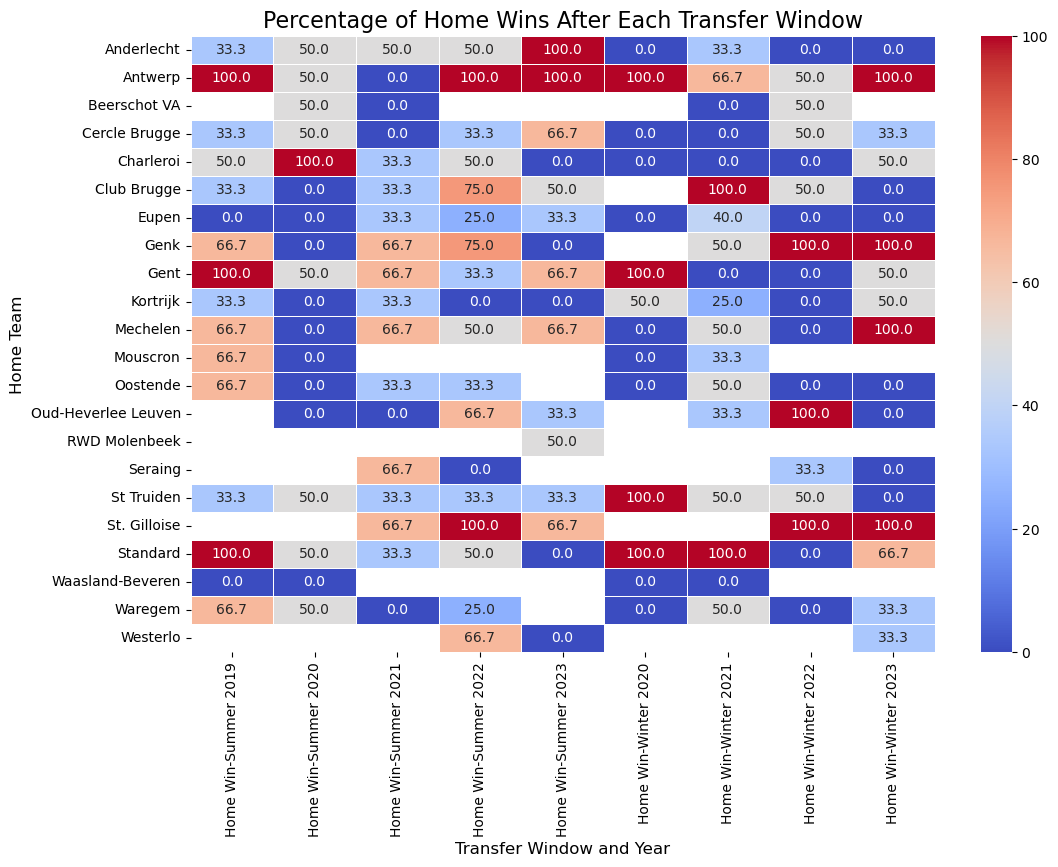

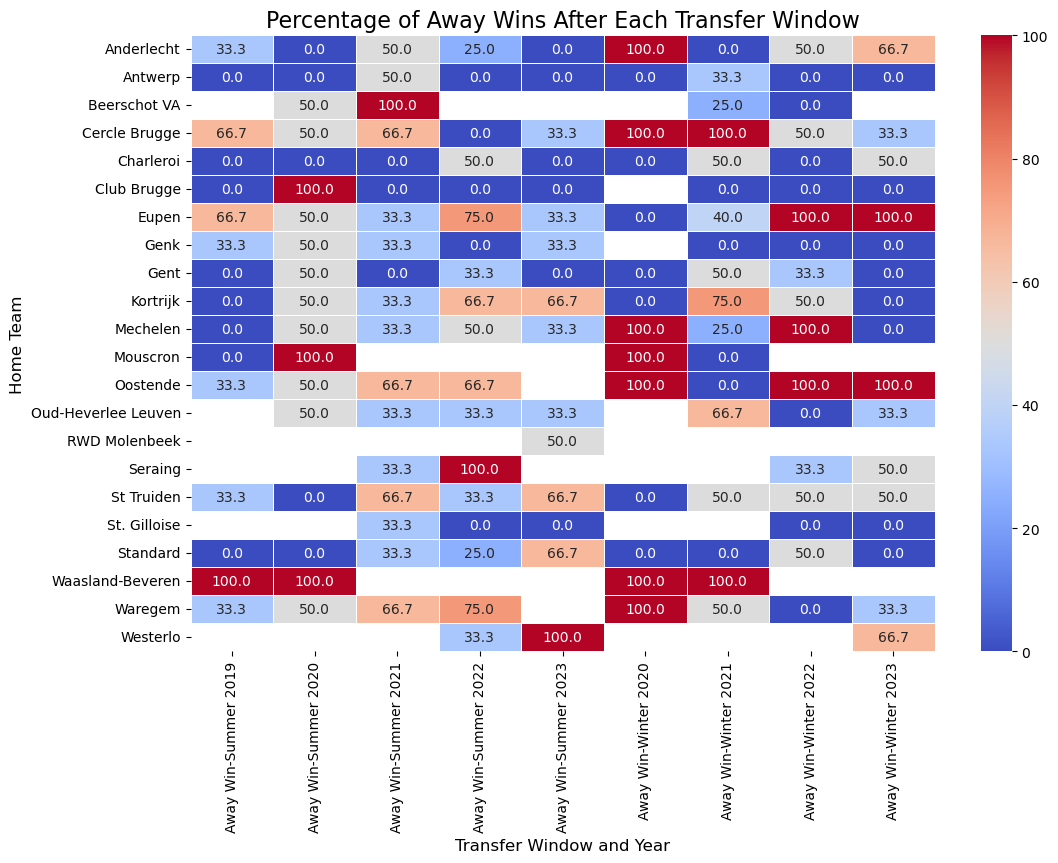

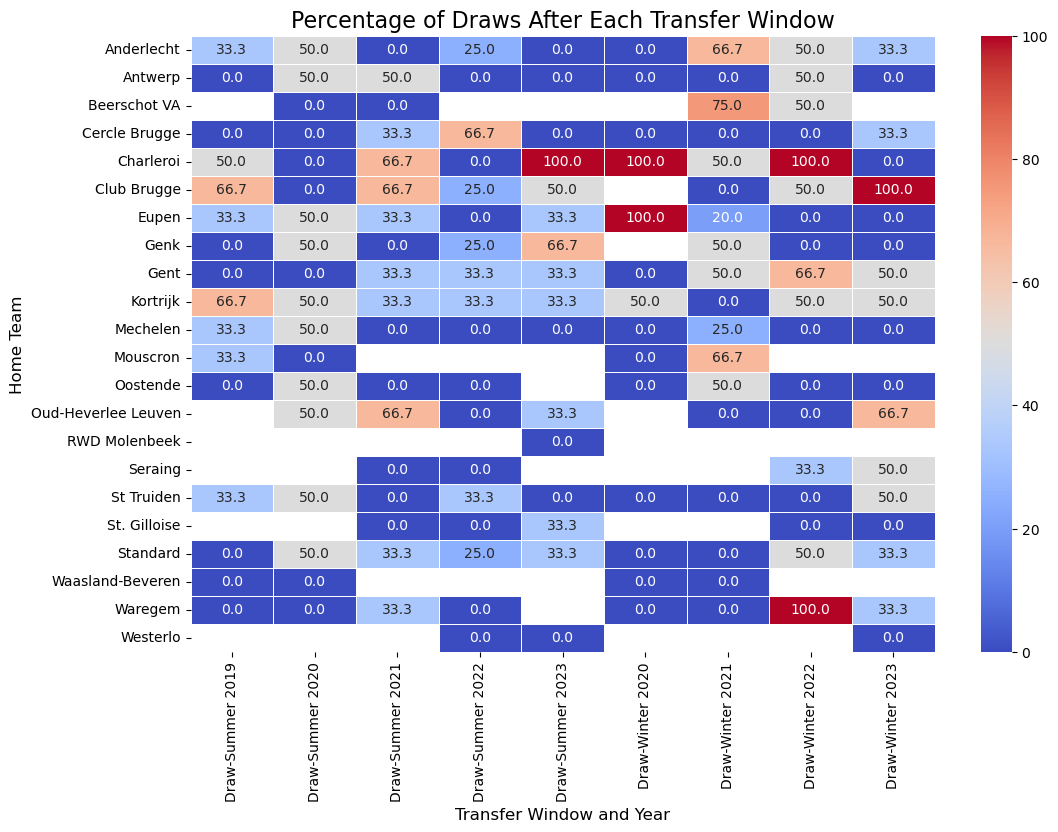

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' is in datetime format and extract 'Year' if not already done
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the transfer window periods with year
transfer_windows = [
    ('Summer', pd.to_datetime(f'{year}-06-01'), pd.to_datetime(f'{year}-09-06')) for year in range(2019, 2024)
] + [
    ('Winter', pd.to_datetime(f'{year}-01-01'), pd.to_datetime(f'{year}-01-31')) for year in range(2019, 2024)
]

# Loop through each transfer window period and calculate the match outcomes
results_by_period = []

for window_name, window_start, window_end in transfer_windows:
    # Filter the data by the current transfer window period
    period_data = merged_data[(merged_data['Date'] >= window_start) & (merged_data['Date'] <= window_end)]
    
    # Calculate the percentage of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result'], 
        normalize='index'
    ) * 100

    # Reset the index and add the period name with the year
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Transfer Window'] = f'{window_name} {window_start.year}'  # Include the year in the label
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win', 'Draw', 'Away Win'], 
    index='HomeTeam', 
    columns='Transfer Window', 
    aggfunc='mean'
)

# Plotting the heatmap for Home Win
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data[['Home Win']], 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title('Percentage of Home Wins After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()

# Plotting the heatmap for Away Win
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data[['Away Win']], 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title('Percentage of Away Wins After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()

# Plotting the heatmap for Draw
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data[['Draw']], 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title('Percentage of Draws After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


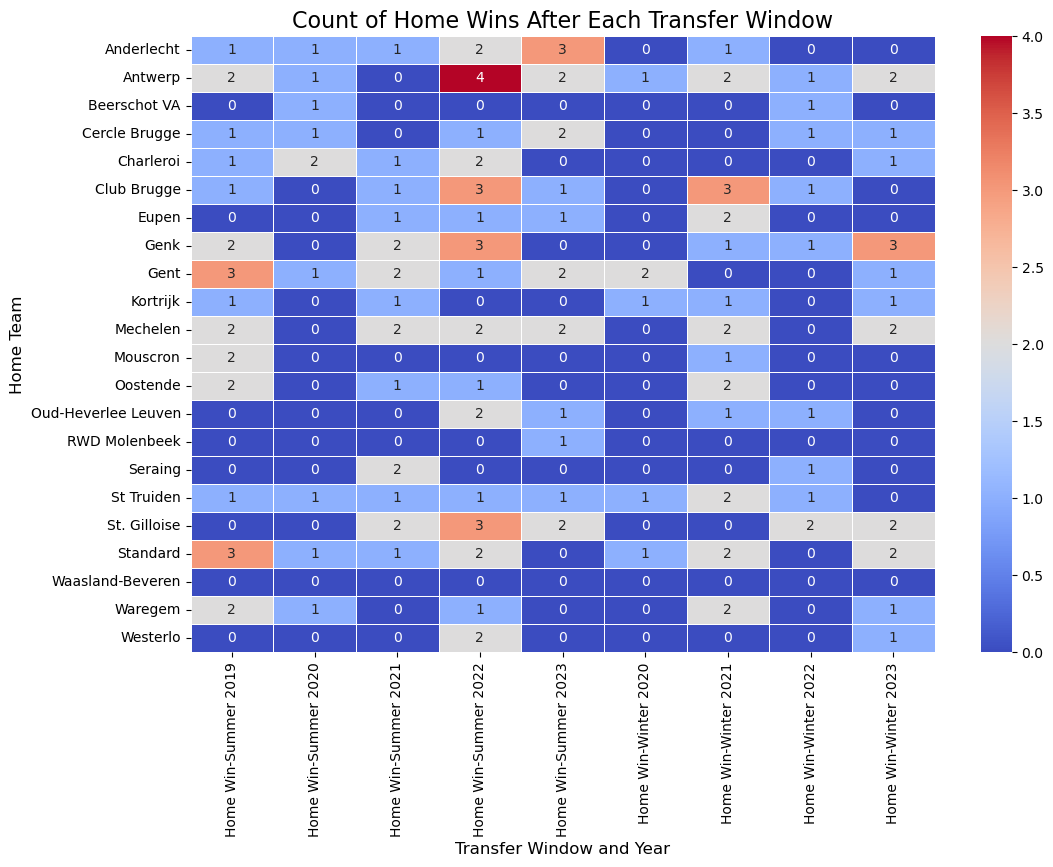

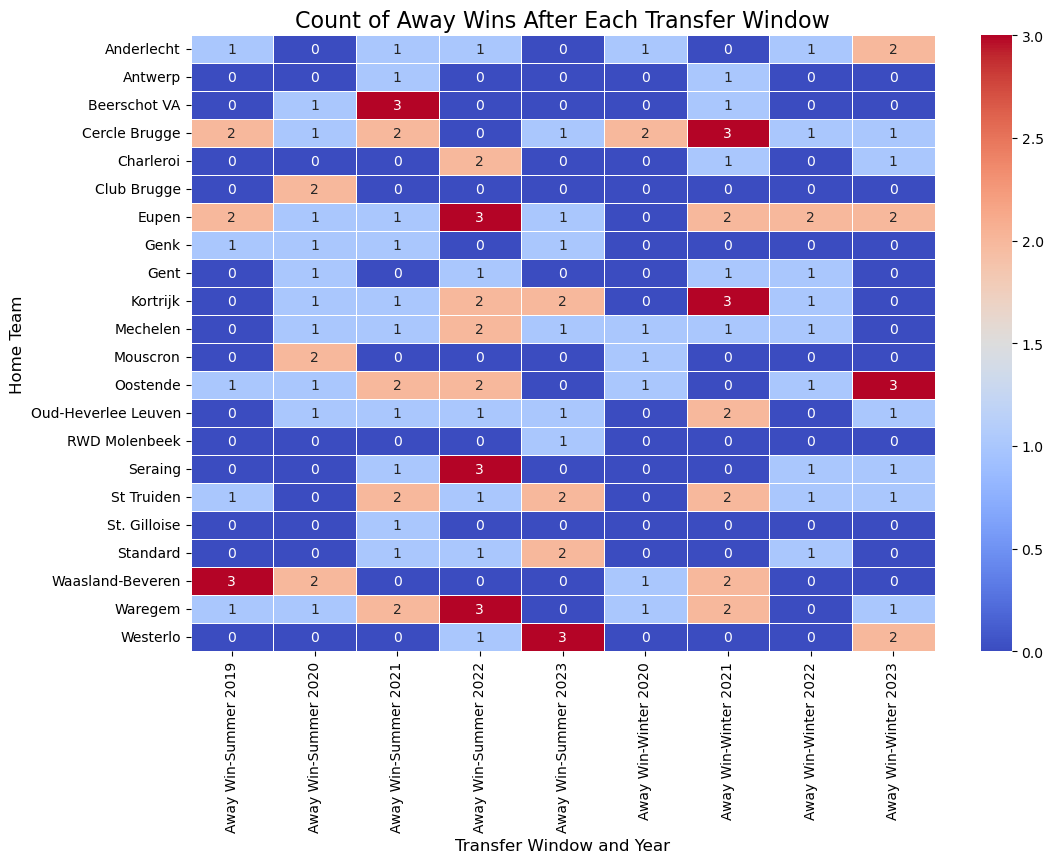

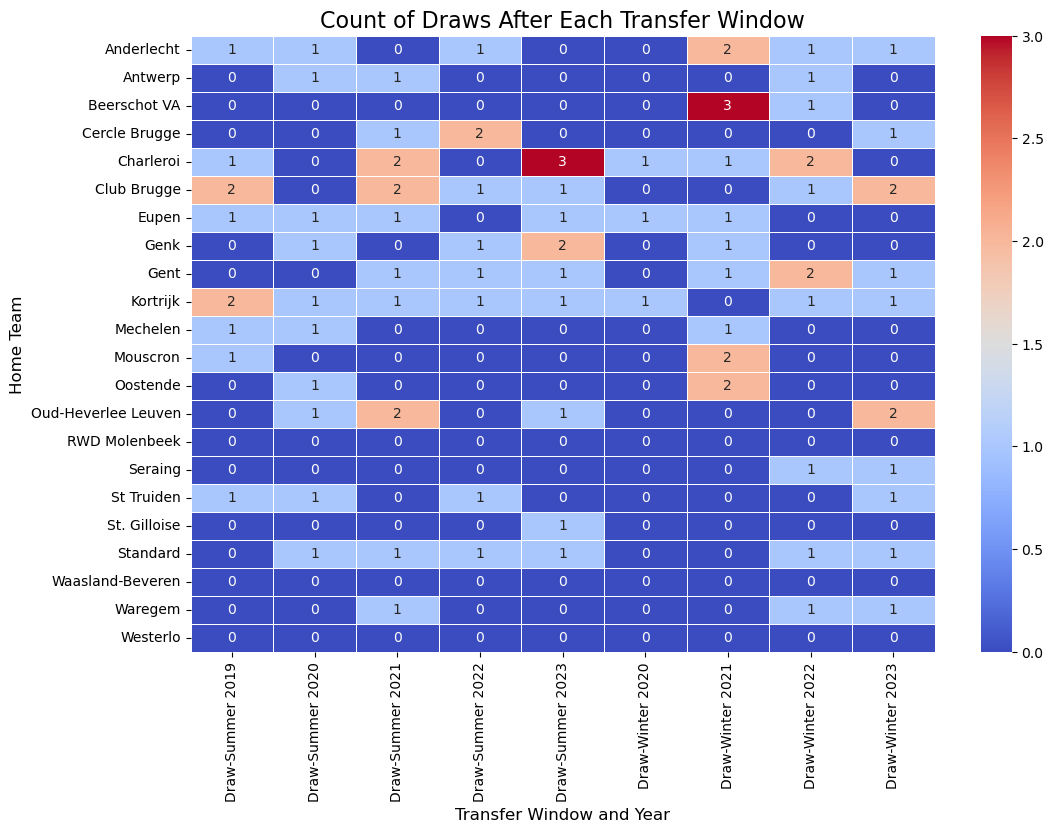

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' is in datetime format and extract 'Year' if not already done
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the transfer window periods with year
transfer_windows = [
    ('Summer', pd.to_datetime(f'{year}-06-01'), pd.to_datetime(f'{year}-09-06')) for year in range(2019, 2024)
] + [
    ('Winter', pd.to_datetime(f'{year}-01-01'), pd.to_datetime(f'{year}-01-31')) for year in range(2019, 2024)
]

# Loop through each transfer window period and calculate the match outcomes
results_by_period = []

for window_name, window_start, window_end in transfer_windows:
    # Filter the data by the current transfer window period
    period_data = merged_data[(merged_data['Date'] >= window_start) & (merged_data['Date'] <= window_end)]
    
    # Calculate the count of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result']
    )

    # Reset the index and add the period name with the year
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Transfer Window'] = f'{window_name} {window_start.year}'  # Include the year in the label
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win', 'Draw', 'Away Win'], 
    index='HomeTeam', 
    columns='Transfer Window', 
    aggfunc='sum'
)

# Fill NaN values with 0 (or another placeholder if needed)
heatmap_data = heatmap_data.fillna(0)

# Convert counts to integers
heatmap_data = heatmap_data.astype(int)

# Plotting the heatmap for Home Win (counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data[['Home Win']], 
    annot=True, 
    fmt="d",  # Display as integer count
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title('Count of Home Wins After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()

# Plotting the heatmap for Away Win (counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data[['Away Win']], 
    annot=True, 
    fmt="d",  # Display as integer count
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title('Count of Away Wins After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()

# Plotting the heatmap for Draw (counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data[['Draw']], 
    annot=True, 
    fmt="d",  # Display as integer count
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title('Count of Draws After Each Transfer Window', fontsize=16)
plt.xlabel('Transfer Window and Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


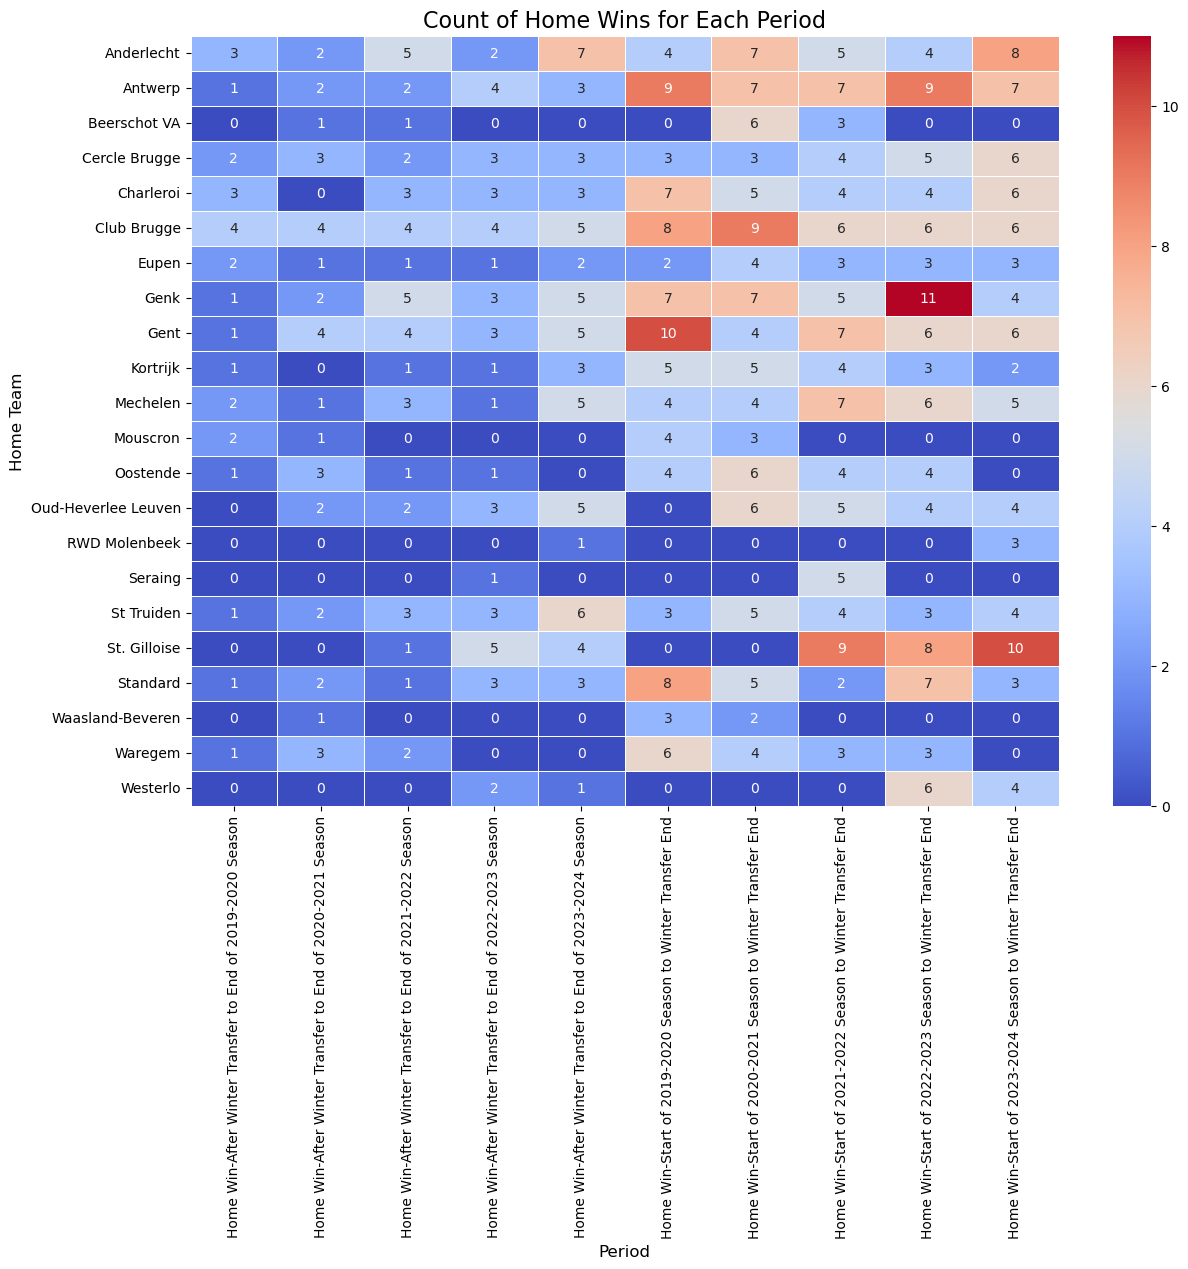

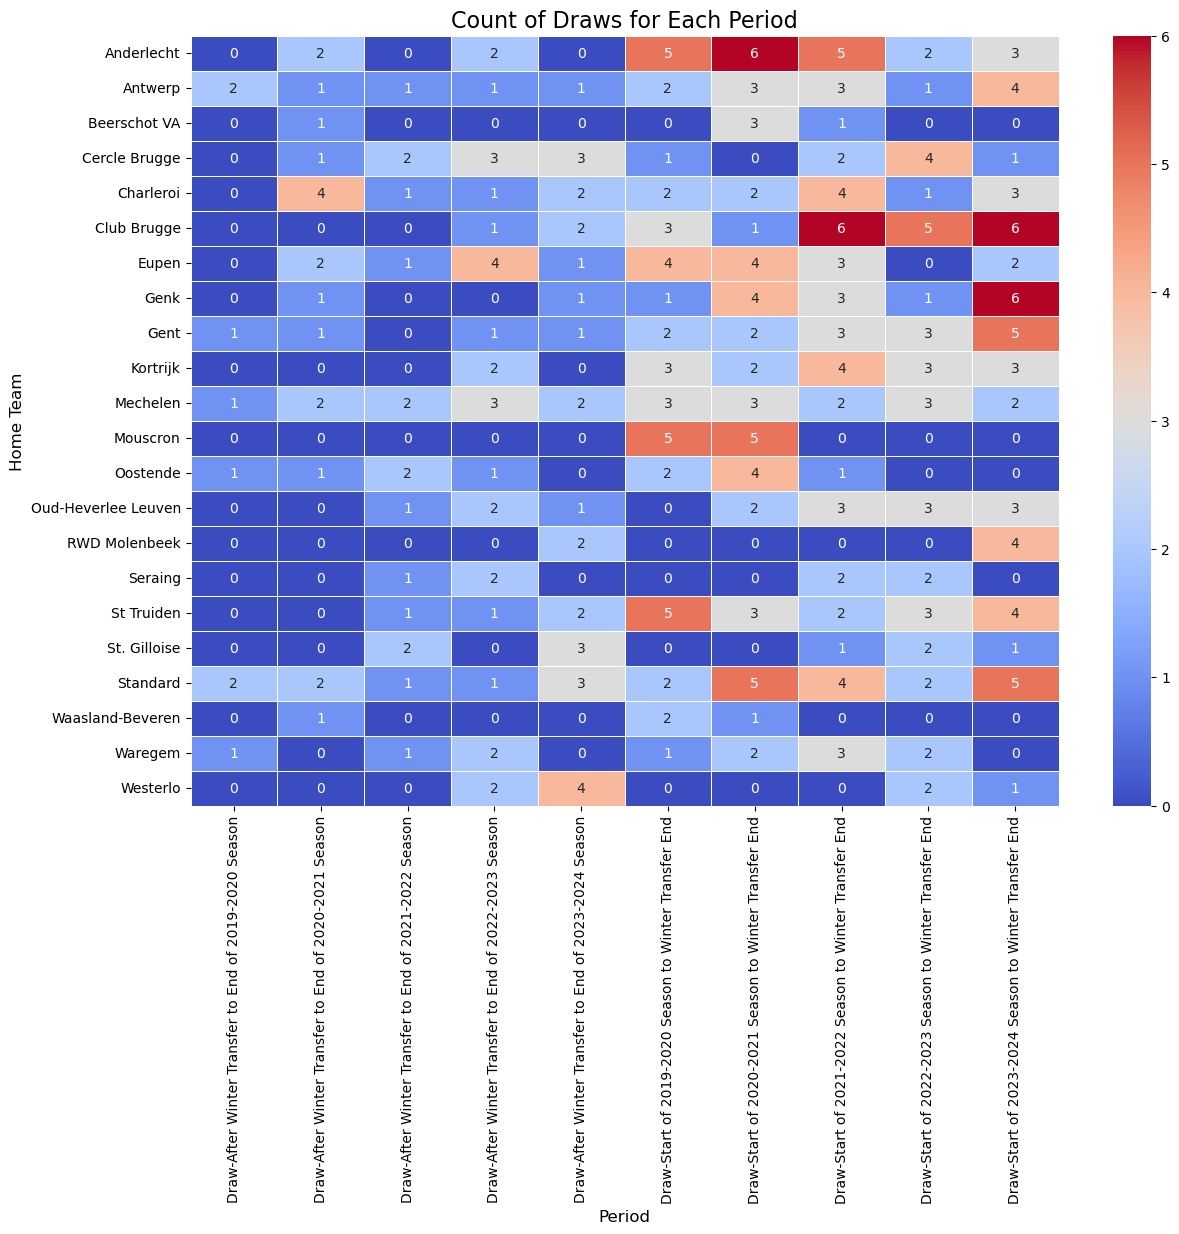

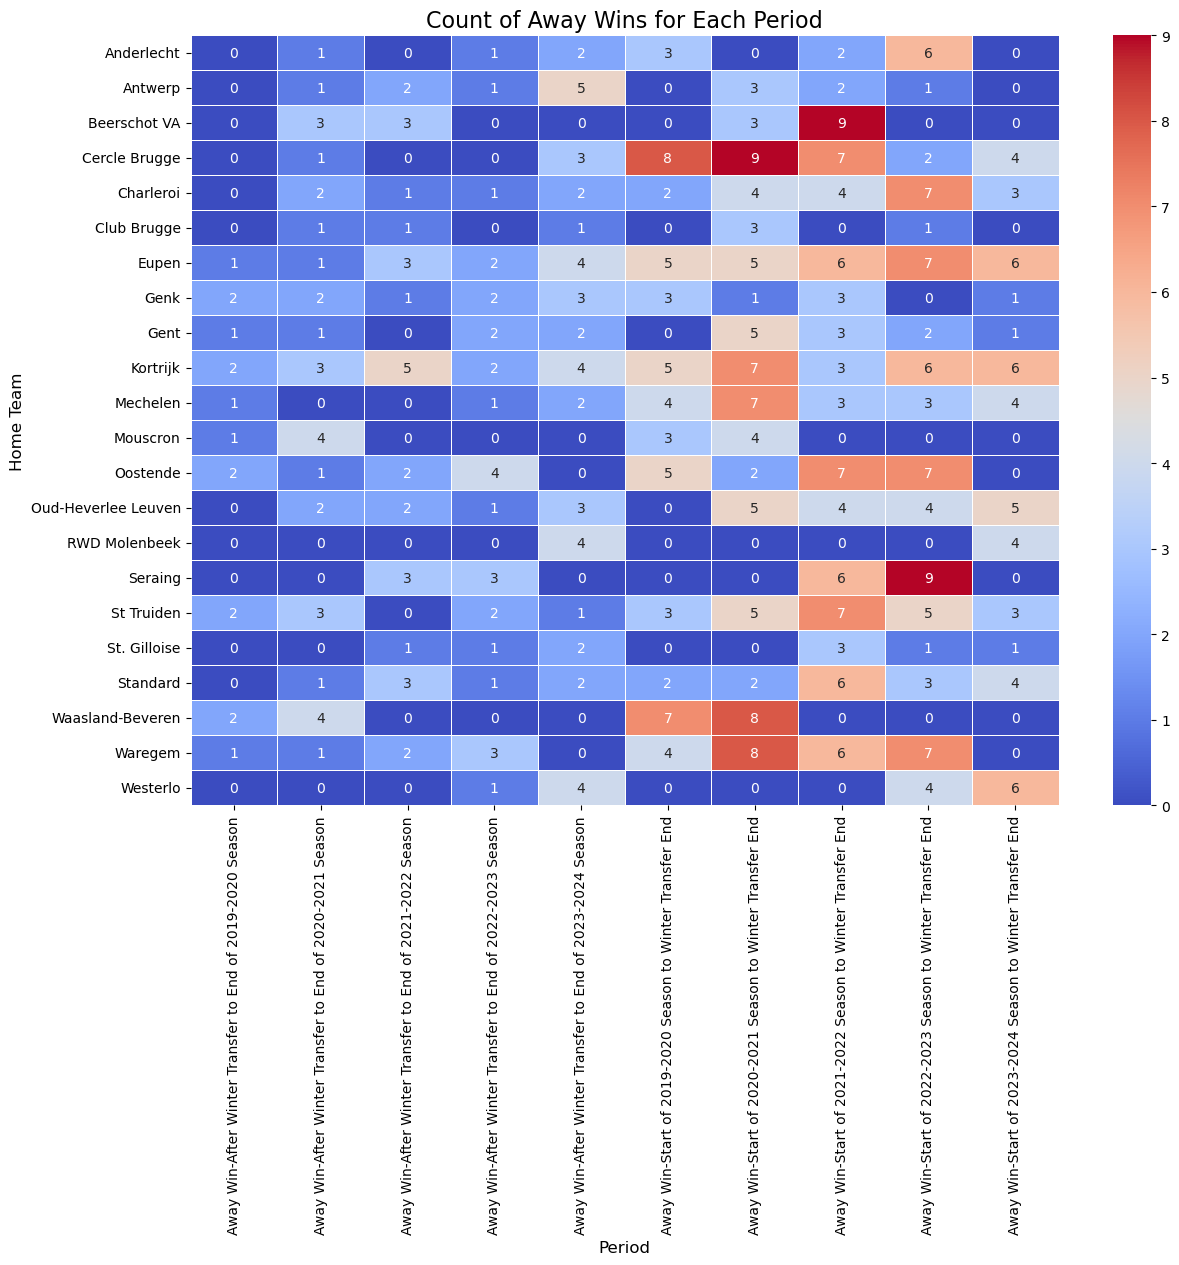

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' is in datetime format
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the season start and end dates
season_dates = {
    2019: (pd.to_datetime('2019-07-01'), pd.to_datetime('2020-05-31')),
    2020: (pd.to_datetime('2020-07-01'), pd.to_datetime('2021-05-31')),
    2021: (pd.to_datetime('2021-07-01'), pd.to_datetime('2022-05-31')),
    2022: (pd.to_datetime('2022-07-01'), pd.to_datetime('2023-05-31')),
    2023: (pd.to_datetime('2023-07-01'), pd.to_datetime('2024-05-31')),
}

# Define the Winter Transfer Window end dates
winter_window_ends = {
    2019: pd.to_datetime('2020-01-31'),
    2020: pd.to_datetime('2021-01-31'),
    2021: pd.to_datetime('2022-01-31'),
    2022: pd.to_datetime('2023-01-31'),
    2023: pd.to_datetime('2024-01-31'),
}

# Create intervals for analysis
analysis_periods = []

for year, (season_start, season_end) in season_dates.items():
    winter_end = winter_window_ends[year]
    analysis_periods.append((f'Start of {year}-{year+1} Season to Winter Transfer End', season_start, winter_end))
    analysis_periods.append((f'After Winter Transfer to End of {year}-{year+1} Season', winter_end, season_end))

# Loop through each analysis period and calculate the match outcomes
results_by_period = []

for period_name, period_start, period_end in analysis_periods:
    # Filter the data for the current period
    period_data = merged_data[(merged_data['Date'] >= period_start) & (merged_data['Date'] <= period_end)]
    
    # Calculate the count of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result']
    )

    # Reset the index and add the period name
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Period'] = period_name
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win', 'Draw', 'Away Win'], 
    index='HomeTeam', 
    columns='Period', 
    aggfunc='sum'
)

# Fill NaN values with 0
heatmap_data = heatmap_data.fillna(0)

# Convert to integers
heatmap_data = heatmap_data.astype(int)

# Plotting the heatmaps
for result_type in ['Home Win', 'Draw', 'Away Win']:
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        heatmap_data[[result_type]], 
        annot=True, 
        fmt="d",  # Display as integer count
        cmap='coolwarm', 
        linewidths=0.5
    )
    plt.title(f'Count of {result_type}s for Each Period', fontsize=16)
    plt.xlabel('Period', fontsize=12)
    plt.ylabel('Home Team', fontsize=12)
    plt.show()


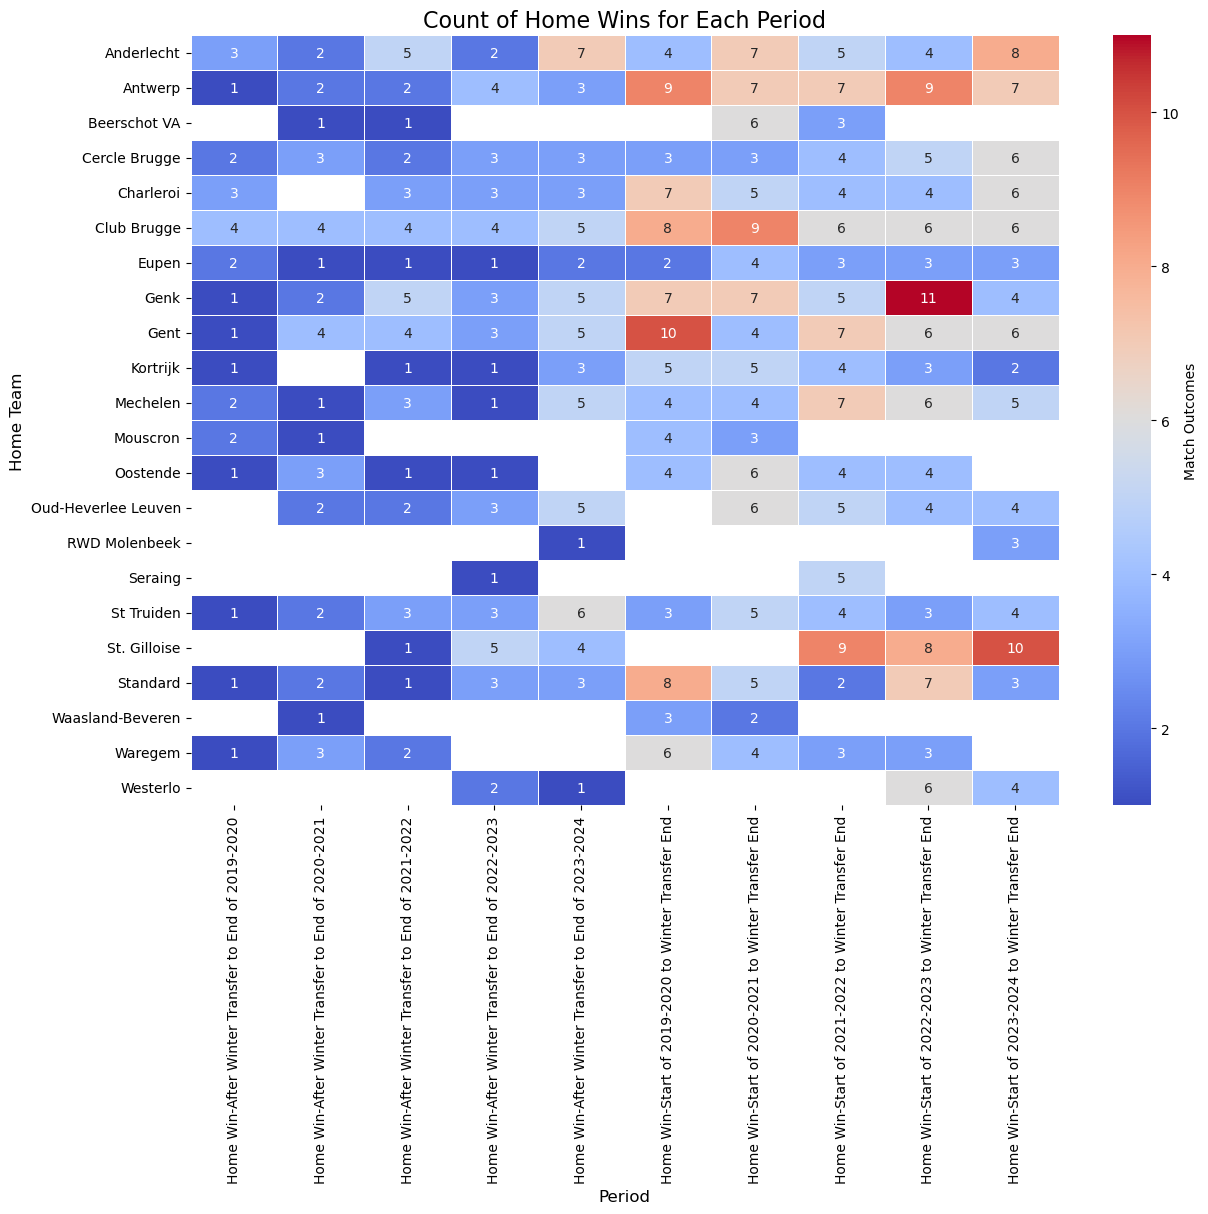

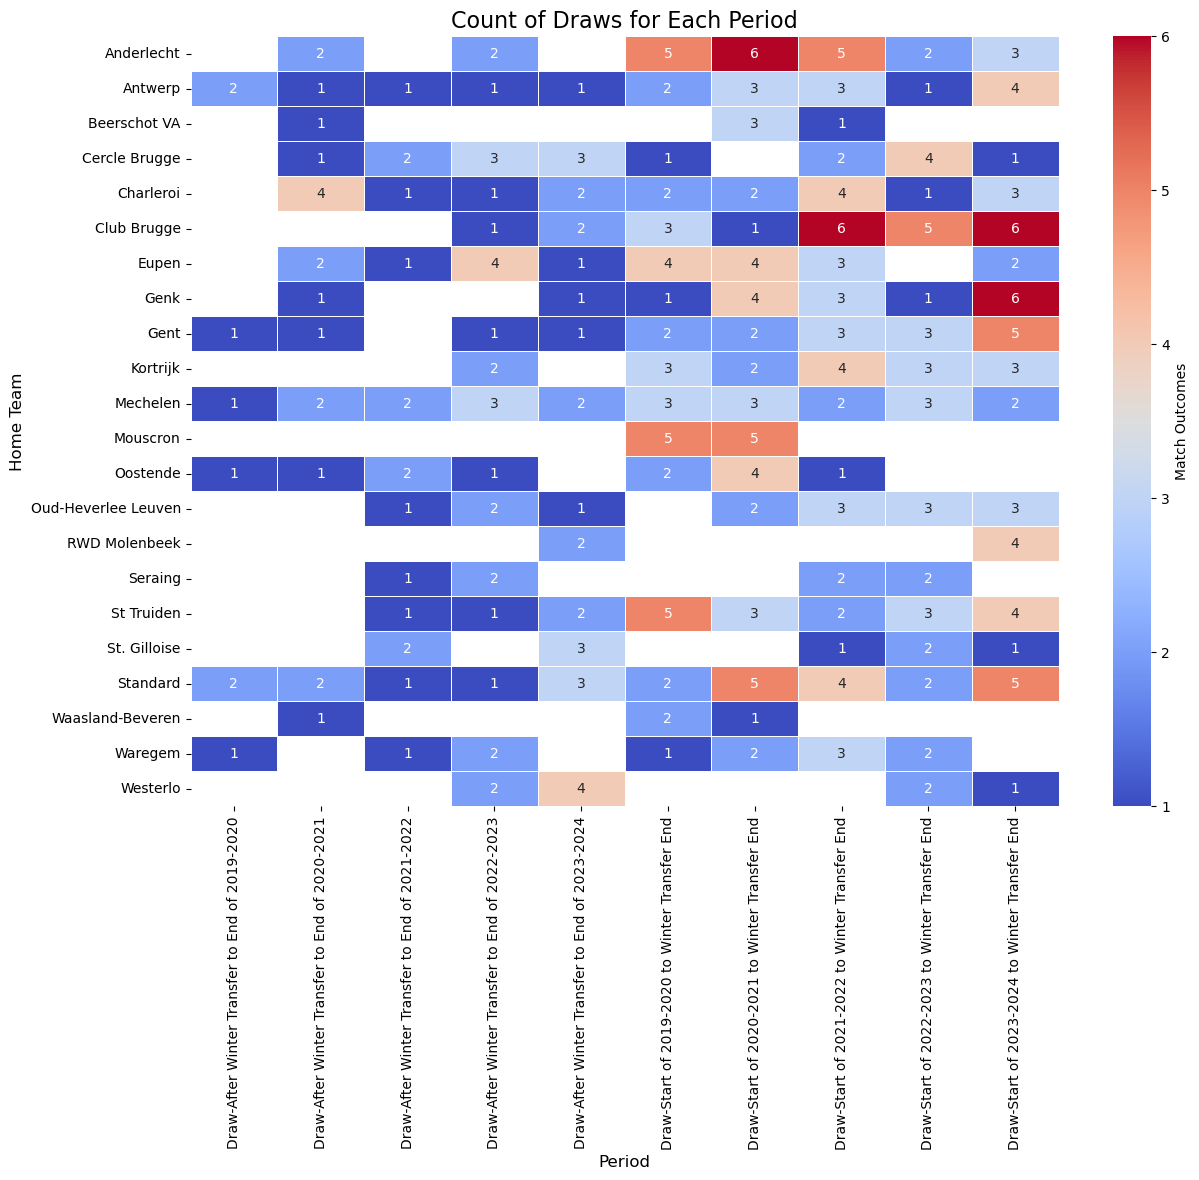

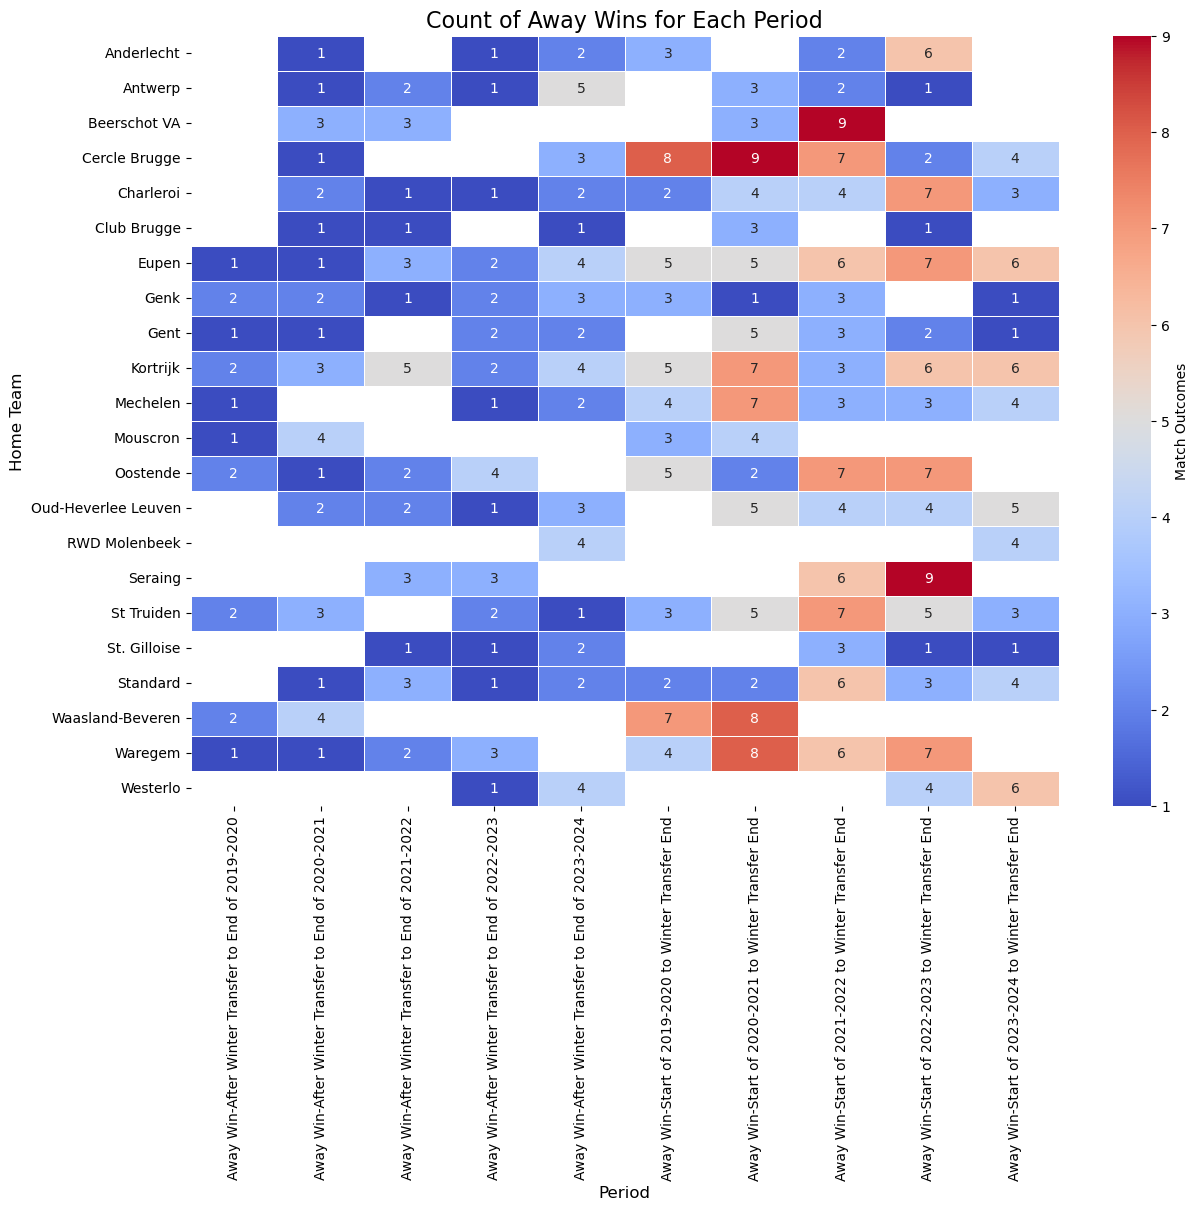

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'Date' is in datetime format
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the season start and end dates using the provided dates
season_dates = {
    '2019-2020': (pd.to_datetime('2019-07-26'), pd.to_datetime('2020-05-15')),
    '2020-2021': (pd.to_datetime('2020-08-08'), pd.to_datetime('2021-05-23')),
    '2021-2022': (pd.to_datetime('2021-07-23'), pd.to_datetime('2022-05-22')),
    '2022-2023': (pd.to_datetime('2022-07-22'), pd.to_datetime('2023-06-04')),
    '2023-2024': (pd.to_datetime('2023-07-28'), pd.to_datetime('2024-05-26')),
}

# Define the Winter Transfer Window end dates (using the provided years)
winter_window_ends = {
    '2019-2020': pd.to_datetime('2020-01-31'),
    '2020-2021': pd.to_datetime('2021-01-31'),
    '2021-2022': pd.to_datetime('2022-01-31'),
    '2022-2023': pd.to_datetime('2023-01-31'),
    '2023-2024': pd.to_datetime('2024-01-31'),
}

# Create intervals for analysis
analysis_periods = []

for season, (season_start, season_end) in season_dates.items():
    winter_end = winter_window_ends[season]
    analysis_periods.append((f'Start of {season} to Winter Transfer End', season_start, winter_end))
    analysis_periods.append((f'After Winter Transfer to End of {season}', winter_end, season_end))

# Loop through each analysis period and calculate the match outcomes
results_by_period = []

for period_name, period_start, period_end in analysis_periods:
    # Filter the data for the current period
    period_data = merged_data[(merged_data['Date'] >= period_start) & (merged_data['Date'] <= period_end)]
    
    # Calculate the count of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result']
    )

    # Reset the index and add the period name
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Period'] = period_name
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win', 'Draw', 'Away Win'], 
    index='HomeTeam', 
    columns='Period', 
    aggfunc='sum'
)

# Fill NaN values with NA (leave them as NaN for teams not in a period)
heatmap_data = heatmap_data.applymap(lambda x: np.nan if x == 0 else x)

# Plotting the heatmaps
for result_type in ['Home Win', 'Draw', 'Away Win']:
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        heatmap_data[[result_type]], 
        annot=True, 
        fmt="g",  # Changed from "d" to "g" to handle float and NaN values
        cmap='coolwarm', 
        linewidths=0.5,
        cbar_kws={'label': 'Match Outcomes'}
    )
    plt.title(f'Count of {result_type}s for Each Period', fontsize=16)
    plt.xlabel('Period', fontsize=12)
    plt.ylabel('Home Team', fontsize=12)
    plt.show()


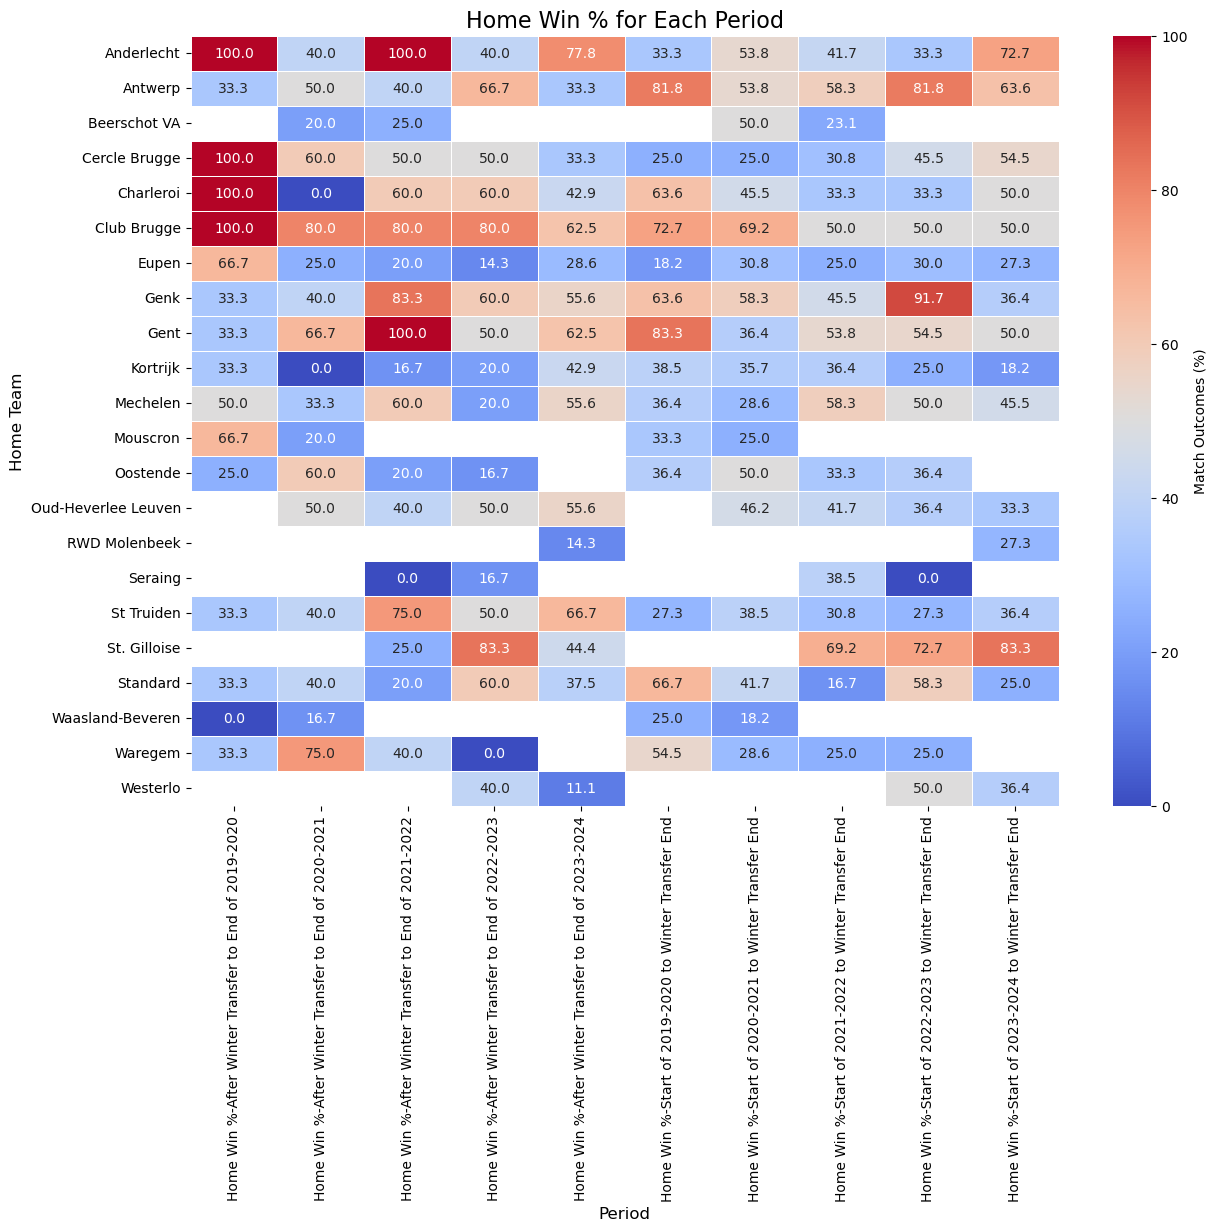

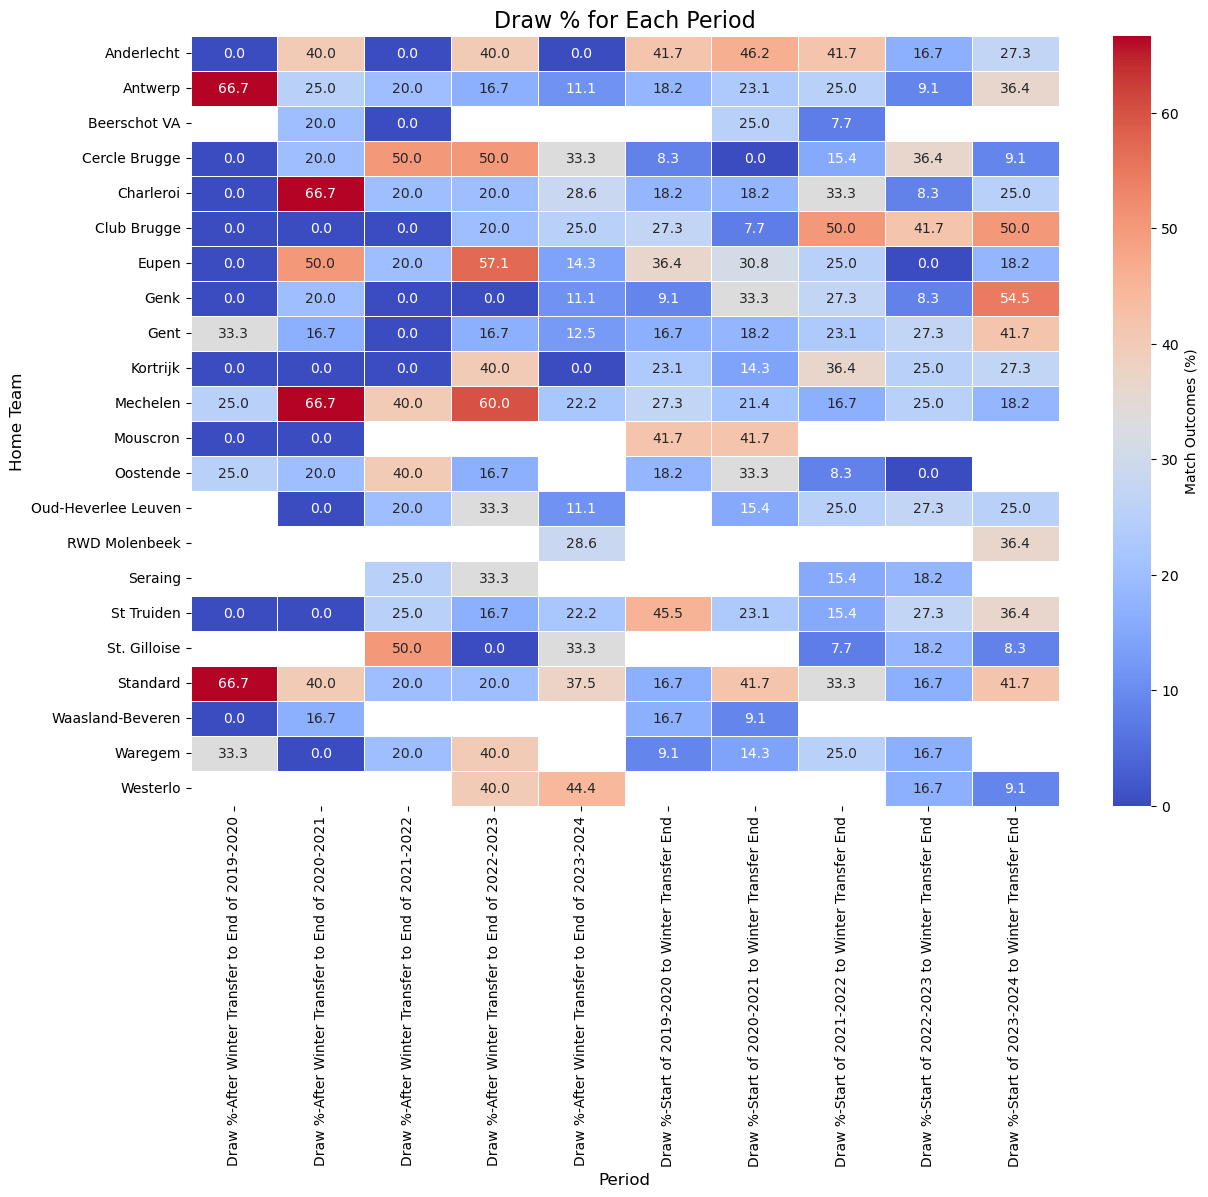

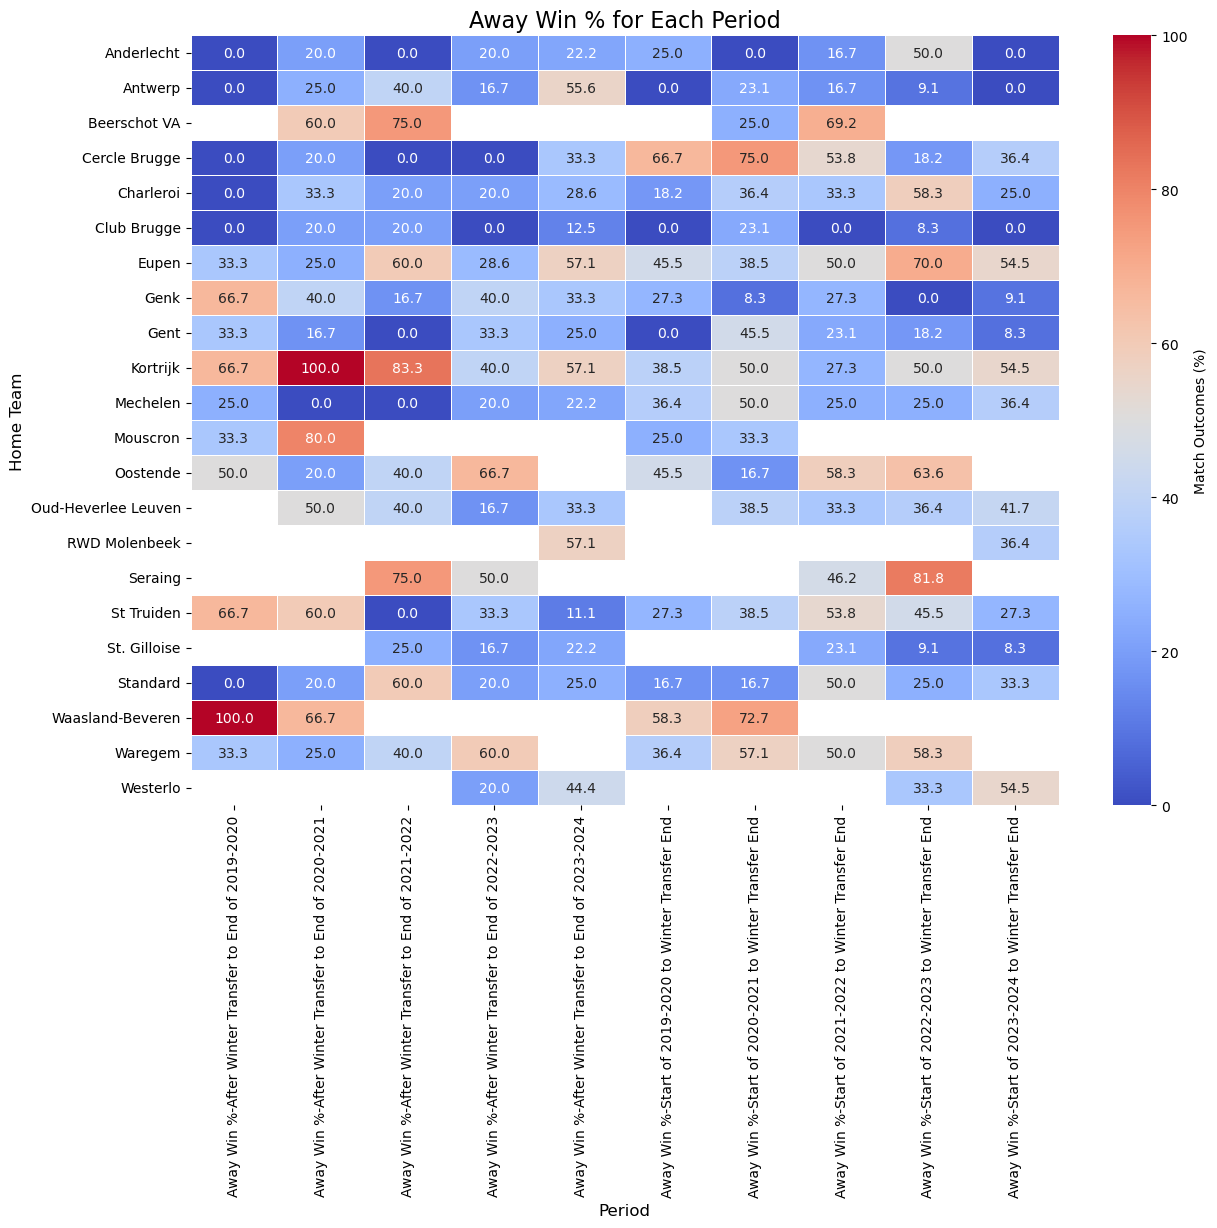

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'Date' is in datetime format
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')
merged_data['Year'] = merged_data['Date'].dt.year

# Map 'FTR' to categorical labels for clarity
ftr_mapping = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
merged_data['Result'] = merged_data['FTR'].map(ftr_mapping)

# Define the season start and end dates using the provided dates
season_dates = {
    '2019-2020': (pd.to_datetime('2019-07-26'), pd.to_datetime('2020-05-15')),
    '2020-2021': (pd.to_datetime('2020-08-08'), pd.to_datetime('2021-05-23')),
    '2021-2022': (pd.to_datetime('2021-07-23'), pd.to_datetime('2022-05-22')),
    '2022-2023': (pd.to_datetime('2022-07-22'), pd.to_datetime('2023-06-04')),
    '2023-2024': (pd.to_datetime('2023-07-28'), pd.to_datetime('2024-05-26')),
}

# Define the Winter Transfer Window end dates (using the provided years)
winter_window_ends = {
    '2019-2020': pd.to_datetime('2020-01-31'),
    '2020-2021': pd.to_datetime('2021-01-31'),
    '2021-2022': pd.to_datetime('2022-01-31'),
    '2022-2023': pd.to_datetime('2023-01-31'),
    '2023-2024': pd.to_datetime('2024-01-31'),
}

# Create intervals for analysis
analysis_periods = []

for season, (season_start, season_end) in season_dates.items():
    winter_end = winter_window_ends[season]
    analysis_periods.append((f'Start of {season} to Winter Transfer End', season_start, winter_end))
    analysis_periods.append((f'After Winter Transfer to End of {season}', winter_end, season_end))

# Loop through each analysis period and calculate the match outcomes
results_by_period = []

for period_name, period_start, period_end in analysis_periods:
    # Filter the data for the current period
    period_data = merged_data[(merged_data['Date'] >= period_start) & (merged_data['Date'] <= period_end)]
    
    # Calculate the count of match outcomes by HomeTeam during this period
    period_crosstab = pd.crosstab(
        period_data['HomeTeam'], 
        period_data['Result']
    )

    # Reset the index and add the period name
    period_crosstab = period_crosstab.reset_index()
    period_crosstab['Period'] = period_name
    
    # Calculate the total number of matches per team for this period
    period_crosstab['Total Matches'] = period_crosstab[['Home Win', 'Draw', 'Away Win']].sum(axis=1)
    
    # Calculate percentages for each result type
    period_crosstab['Home Win %'] = (period_crosstab['Home Win'] / period_crosstab['Total Matches']) * 100
    period_crosstab['Draw %'] = (period_crosstab['Draw'] / period_crosstab['Total Matches']) * 100
    period_crosstab['Away Win %'] = (period_crosstab['Away Win'] / period_crosstab['Total Matches']) * 100
    
    # Keep the percentage columns for the heatmap
    period_crosstab = period_crosstab[['HomeTeam', 'Period', 'Home Win %', 'Draw %', 'Away Win %']]
    
    results_by_period.append(period_crosstab)

# Combine the results for all periods
results_df = pd.concat(results_by_period, ignore_index=True)

# Pivot the data for heatmap plotting
heatmap_data = results_df.pivot_table(
    values=['Home Win %', 'Draw %', 'Away Win %'], 
    index='HomeTeam', 
    columns='Period', 
    aggfunc='mean'
)

# Fill NaN values with NA (leave them as NaN for teams not in a period)
heatmap_data = heatmap_data.applymap(lambda x: np.nan if pd.isna(x) else x)

# Plotting the heatmaps
for result_type in ['Home Win %', 'Draw %', 'Away Win %']:
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        heatmap_data[[result_type]], 
        annot=True, 
        fmt=".1f",  # Format as percentage with one decimal place
        cmap='coolwarm', 
        linewidths=0.5,
        cbar_kws={'label': 'Match Outcomes (%)'}
    )
    plt.title(f'{result_type} for Each Period', fontsize=16)
    plt.xlabel('Period', fontsize=12)
    plt.ylabel('Home Team', fontsize=12)
    plt.show()


# 2. Percentage of Match Outcomes by Home Team and Year

In [39]:
# Create a crosstab of HomeTeam, Year, and Result
yearly_crosstab = pd.crosstab(
    [merged_data['HomeTeam'], merged_data['Year']], 
    merged_data['Result'], 
    normalize='index'
) * 100

# Reset index to flatten the DataFrame
yearly_crosstab = yearly_crosstab.reset_index()


In [40]:
# Pivot the data for Home Win %
home_win_pivot = yearly_crosstab.pivot(
    index='HomeTeam', 
    columns='Year', 
    values='Home Win'
).fillna(0)


In [41]:
# Pivot the data for Draw %
draw_pivot = yearly_crosstab.pivot(
    index='HomeTeam', 
    columns='Year', 
    values='Draw'
).fillna(0)


In [42]:
# Pivot the data for Away Win %
away_win_pivot = yearly_crosstab.pivot(
    index='HomeTeam', 
    columns='Year', 
    values='Away Win'
).fillna(0)


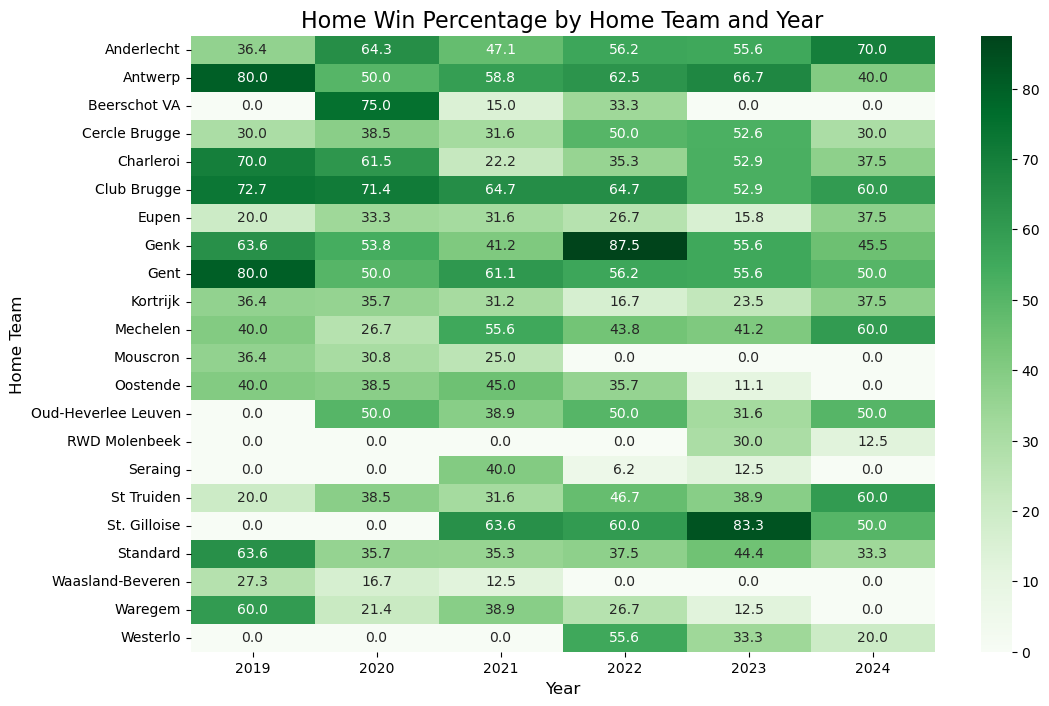

In [43]:
# Heatmap for Home Win Percentage
plt.figure(figsize=(12, 8))
sns.heatmap(
    home_win_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap='Greens'
)
plt.title('Home Win Percentage by Home Team and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


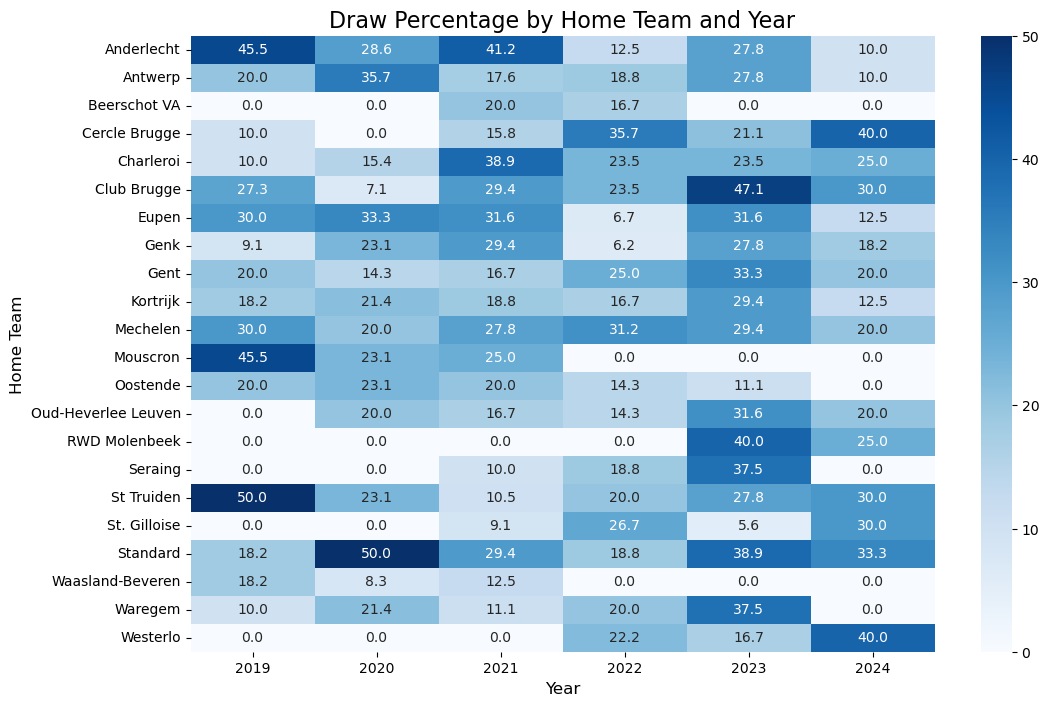

In [44]:
# Heatmap for Draw Percentage
plt.figure(figsize=(12, 8))
sns.heatmap(
    draw_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap='Blues'
)
plt.title('Draw Percentage by Home Team and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


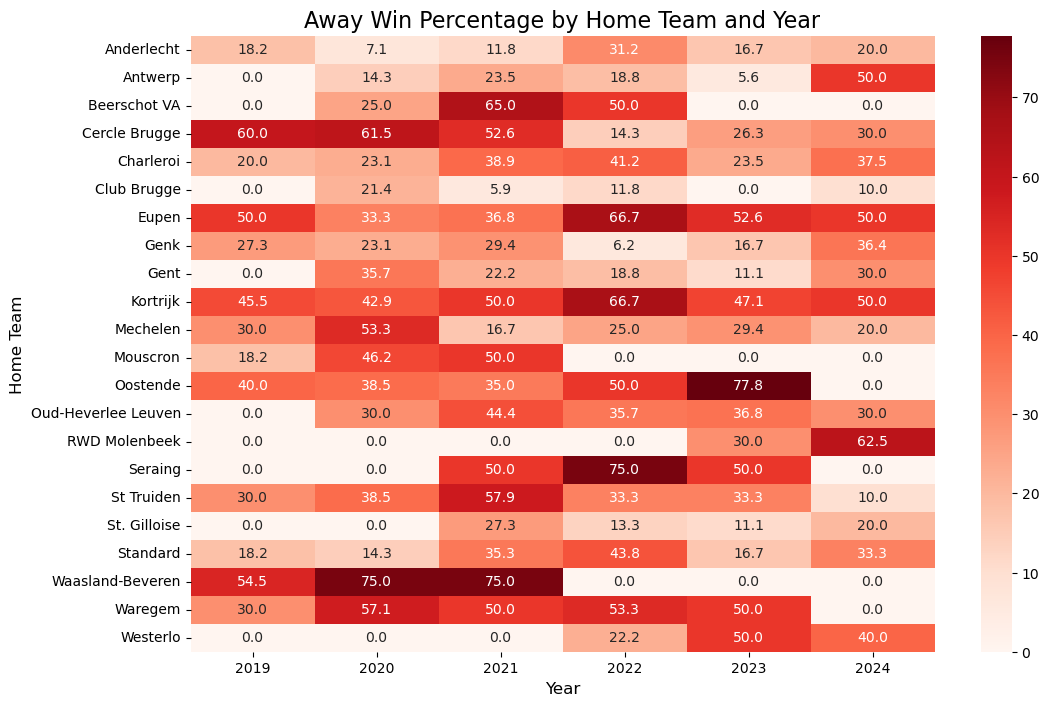

In [45]:
# Heatmap for Away Win Percentage
plt.figure(figsize=(12, 8))
sns.heatmap(
    away_win_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap='Reds'
)
plt.title('Away Win Percentage by Home Team and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


In [46]:
# Melt the yearly_crosstab DataFrame
melted_crosstab = yearly_crosstab.melt(
    id_vars=['HomeTeam', 'Year'], 
    value_vars=['Home Win', 'Draw', 'Away Win'], 
    var_name='Result', 
    value_name='Percentage'
)

# Create a pivot table with 'HomeTeam' and 'Result' as index and 'Year' as columns
combined_pivot = melted_crosstab.pivot_table(
    index=['HomeTeam', 'Result'], 
    columns='Year', 
    values='Percentage'
).fillna(0)


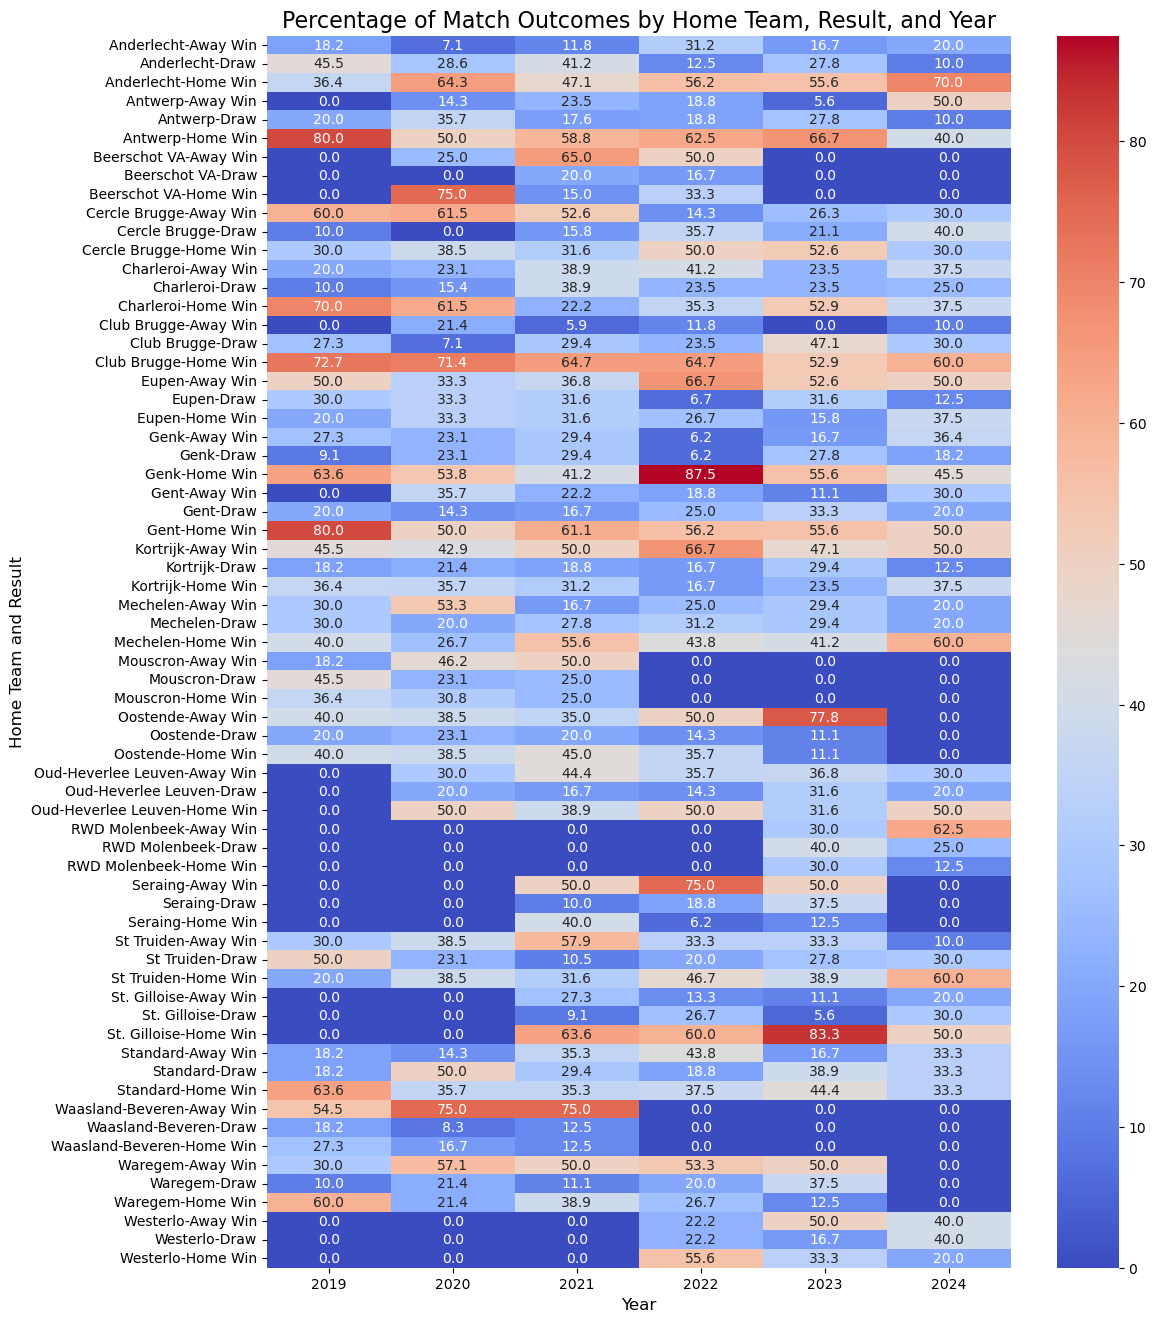

In [47]:
# Heatmap for Combined Outcomes
plt.figure(figsize=(12, 16))
sns.heatmap(
    combined_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm'
)
plt.title('Percentage of Match Outcomes by Home Team, Result, and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team and Result', fontsize=12)
plt.show()


# using the actual numbers

In [48]:
# Overall counts of match outcomes by HomeTeam
overall_counts = pd.crosstab(
    merged_data['HomeTeam'], 
    merged_data['Result']
).reset_index()


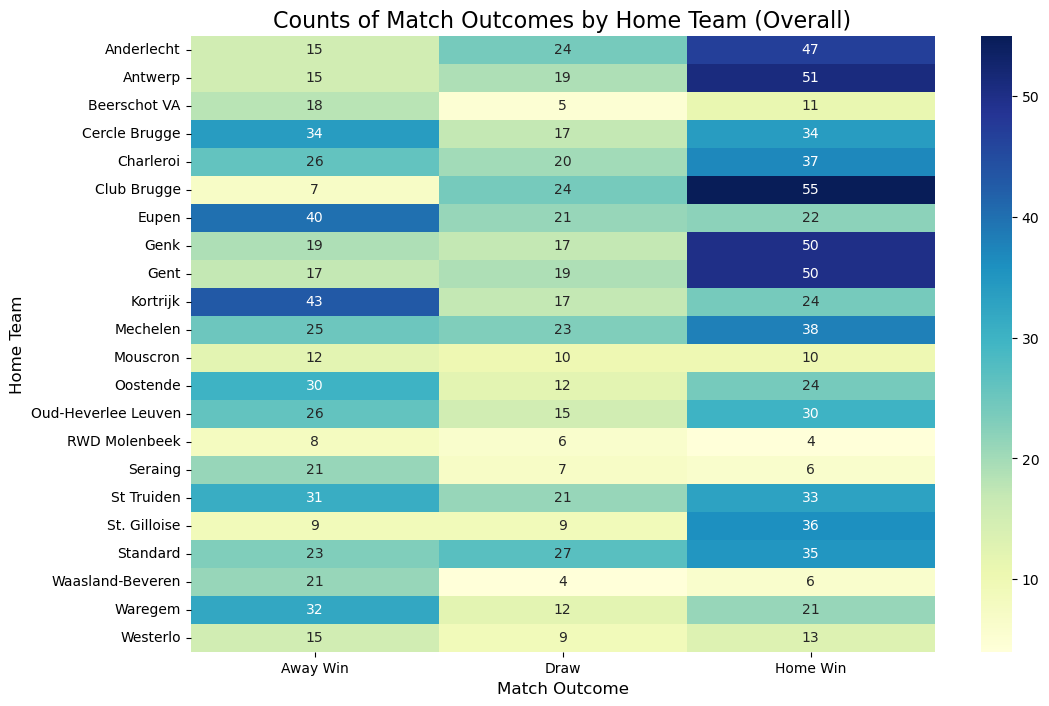

In [49]:
# Set the index to 'HomeTeam' for plotting
overall_counts.set_index('HomeTeam', inplace=True)

# Heatmap for overall counts
plt.figure(figsize=(12, 8))
sns.heatmap(
    overall_counts, 
    annot=True, 
    fmt="d",       # Format as integers
    cmap='YlGnBu'  # Choose a color map suitable for counts
)
plt.title('Counts of Match Outcomes by Home Team (Overall)', fontsize=16)
plt.xlabel('Match Outcome', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


In [50]:
# Create a crosstab of HomeTeam, Year, and Result
yearly_counts = pd.crosstab(
    [merged_data['HomeTeam'], merged_data['Year']], 
    merged_data['Result']
).reset_index()


In [51]:
# Create a crosstab of HomeTeam, Year, and Result
yearly_counts = pd.crosstab(
    [merged_data['HomeTeam'], merged_data['Year']], 
    merged_data['Result']
).reset_index()


In [52]:
# Pivot the data for Home Win counts
home_win_counts = yearly_counts.pivot(
    index='HomeTeam', 
    columns='Year', 
    values='Home Win'
).fillna(0).astype(int)


In [53]:
# Pivot the data for Draw counts
draw_counts = yearly_counts.pivot(
    index='HomeTeam', 
    columns='Year', 
    values='Draw'
).fillna(0).astype(int)


In [54]:
# Pivot the data for Away Win counts
away_win_counts = yearly_counts.pivot(
    index='HomeTeam', 
    columns='Year', 
    values='Away Win'
).fillna(0).astype(int)


Explanation:

Pivoting Data: Transforms the DataFrame to have 'HomeTeam' as rows and 'Year' as columns, with counts as values.

Filling Missing Values: Replaces NaN with 0 since some teams may not have certain outcomes in a year.

Converting to Integers: Ensures the counts are integers for proper display.

Plotting the Heatmaps

Home Win Counts Heatmap

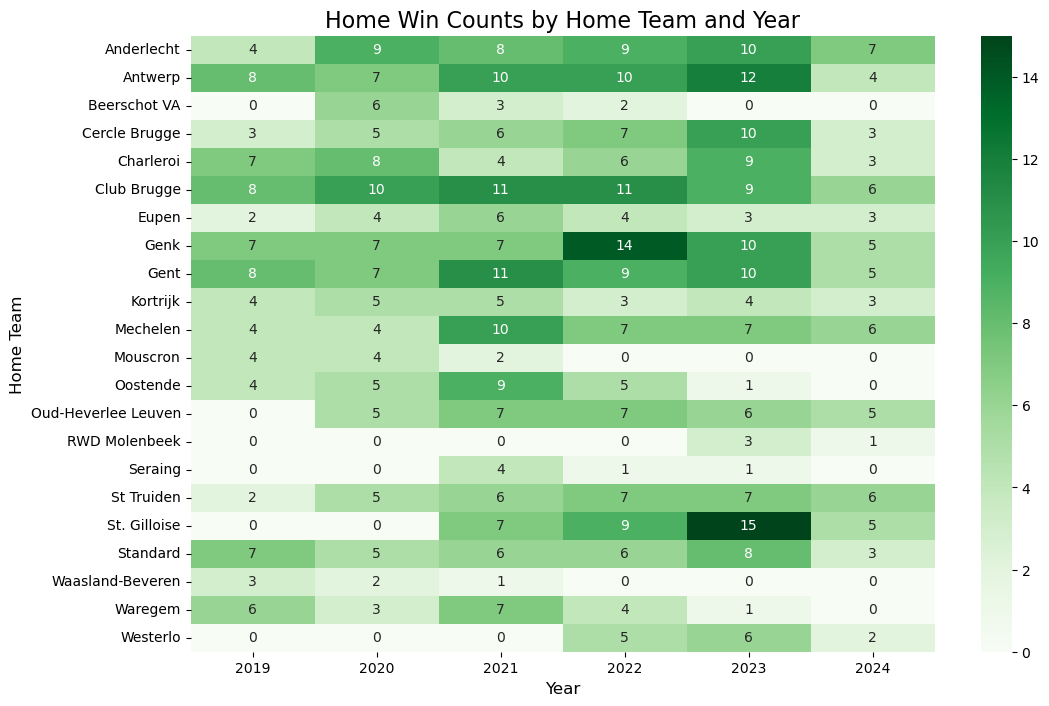

In [55]:
# Heatmap for Home Win Counts
plt.figure(figsize=(12, 8))
sns.heatmap(
    home_win_counts, 
    annot=True, 
    fmt="d", 
    cmap='Greens'
)
plt.title('Home Win Counts by Home Team and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


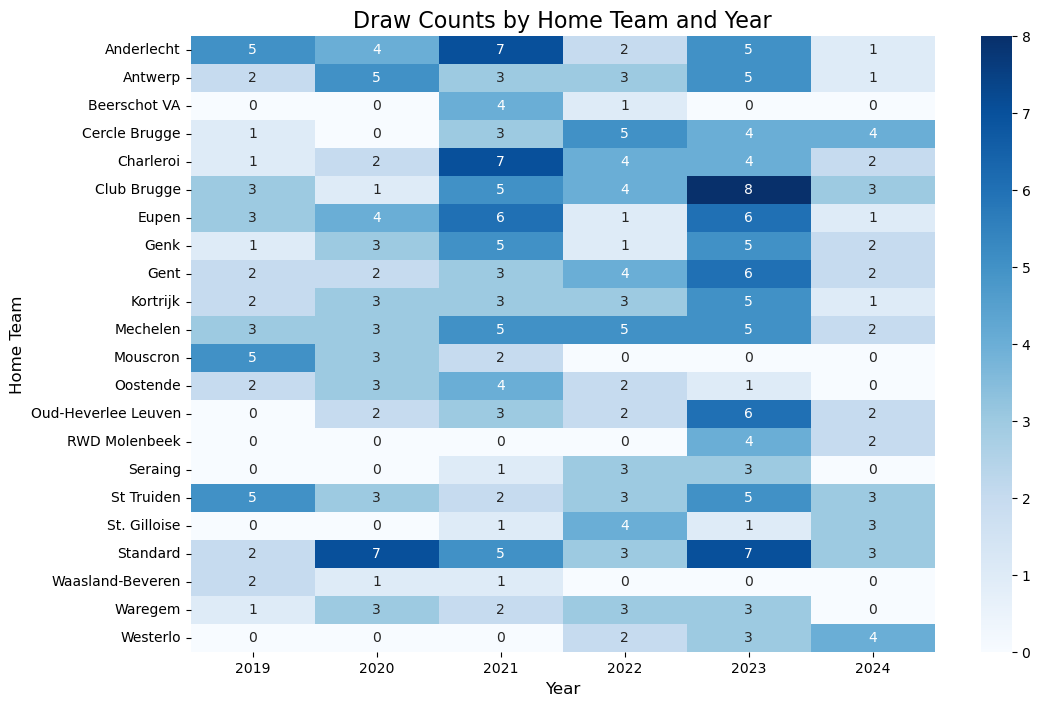

In [56]:
# Heatmap for Draw Counts
plt.figure(figsize=(12, 8))
sns.heatmap(
    draw_counts, 
    annot=True, 
    fmt="d", 
    cmap='Blues'
)
plt.title('Draw Counts by Home Team and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


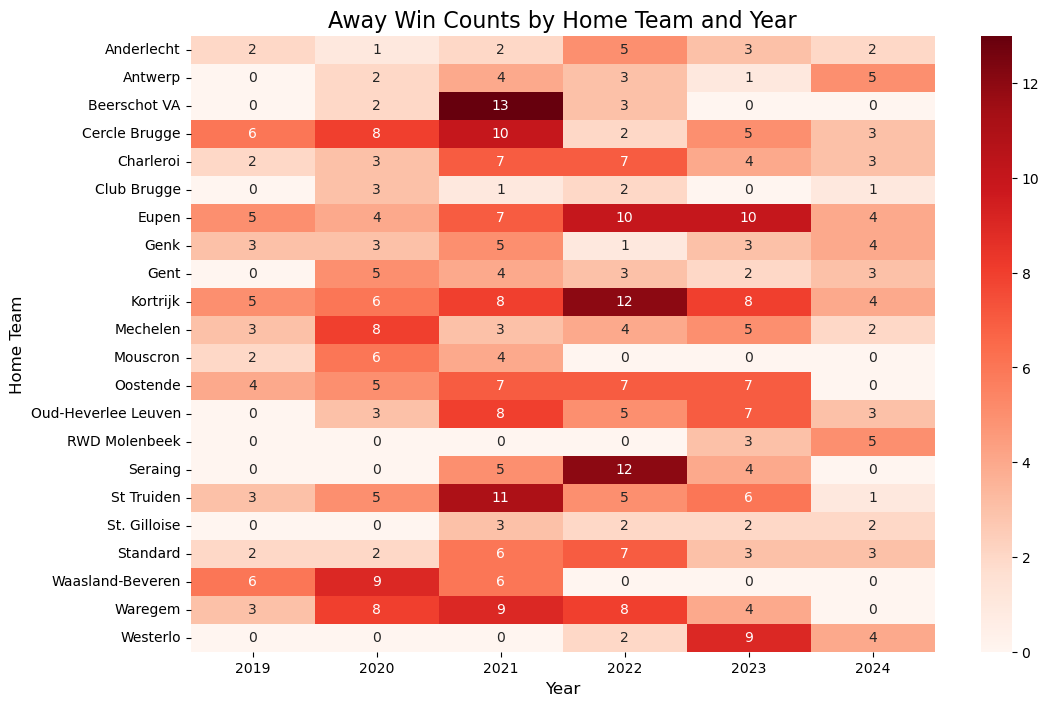

In [57]:
# Heatmap for Away Win Counts
plt.figure(figsize=(12, 8))
sns.heatmap(
    away_win_counts, 
    annot=True, 
    fmt="d", 
    cmap='Reds'
)
plt.title('Away Win Counts by Home Team and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team', fontsize=12)
plt.show()


In [58]:
# Melt the yearly_counts DataFrame
melted_counts = yearly_counts.melt(
    id_vars=['HomeTeam', 'Year'], 
    value_vars=['Home Win', 'Draw', 'Away Win'], 
    var_name='Result', 
    value_name='Count'
)

# Create a pivot table with 'HomeTeam' and 'Result' as index and 'Year' as columns
combined_counts = melted_counts.pivot_table(
    index=['HomeTeam', 'Result'], 
    columns='Year', 
    values='Count'
).fillna(0).astype(int)


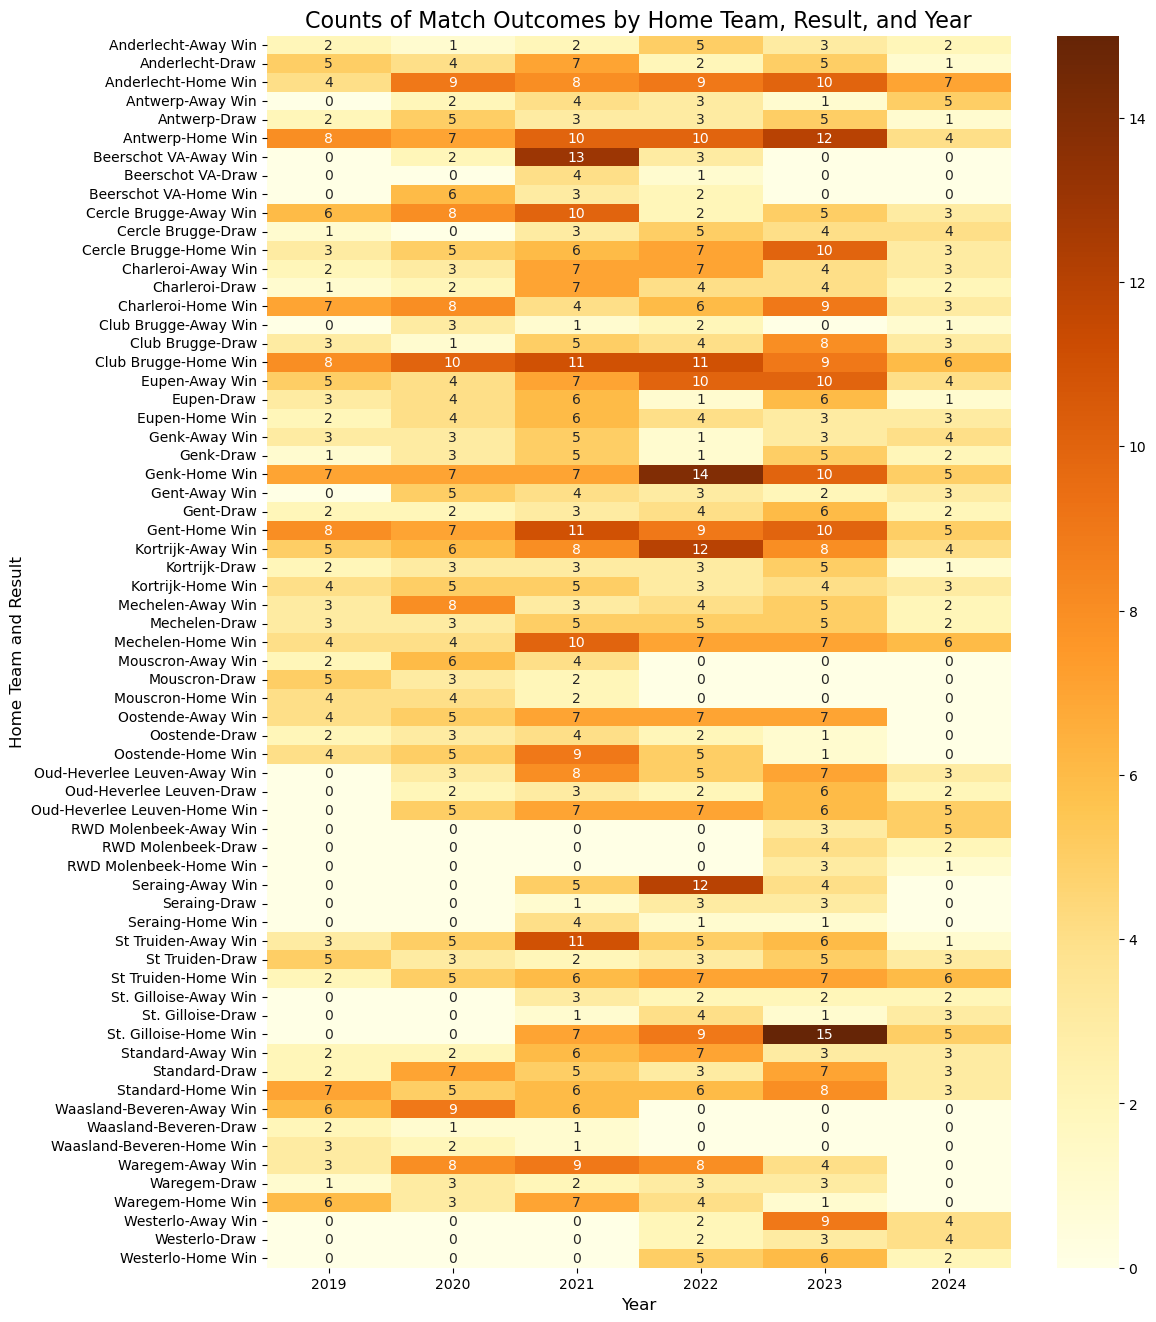

In [59]:
# Heatmap for Combined Counts
plt.figure(figsize=(12, 16))
sns.heatmap(
    combined_counts, 
    annot=True, 
    fmt="d", 
    cmap='YlOrBr'
)
plt.title('Counts of Match Outcomes by Home Team, Result, and Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Home Team and Result', fontsize=12)
plt.show()


4. Sorting Teams by Total Matches (Optional)

In [60]:
# Calculate total home matches for each team
total_home_matches = merged_data.groupby('HomeTeam').size().reset_index(name='Total_Matches')

# Sort teams based on total matches
sorted_teams = total_home_matches.sort_values('Total_Matches', ascending=False)['HomeTeam']

# Reindex the counts DataFrames
home_win_counts = home_win_counts.reindex(sorted_teams)
draw_counts = draw_counts.reindex(sorted_teams)
away_win_counts = away_win_counts.reindex(sorted_teams)


## .6. Relationship Between Shots and Goals

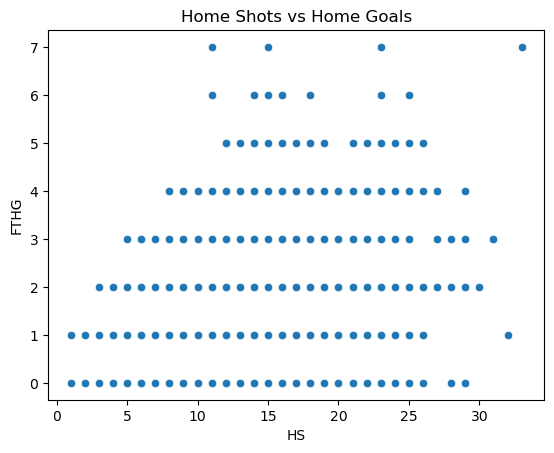

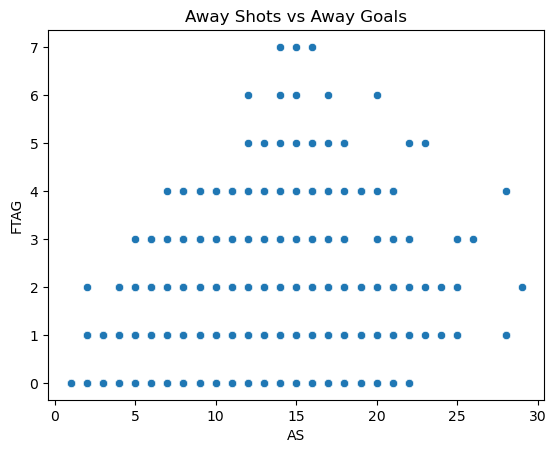

In [61]:
# Scatter plot of Home Shots vs Home Goals
sns.scatterplot(x='HS', y='FTHG', data=merged_data)
plt.title('Home Shots vs Home Goals')
plt.show()

# Scatter plot of Away Shots vs Away Goals
sns.scatterplot(x='AS', y='FTAG', data=merged_data)
plt.title('Away Shots vs Away Goals')
plt.show()


5.7. Bookings Analysis

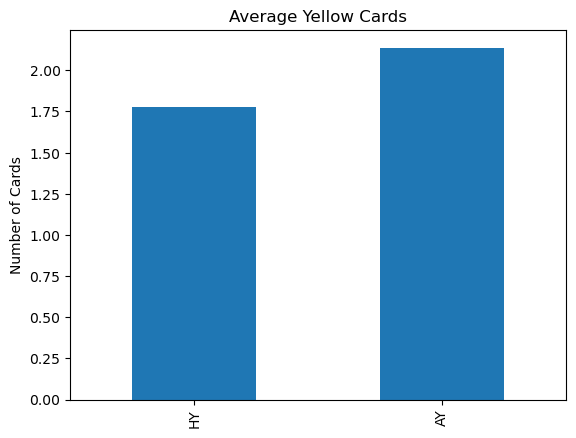

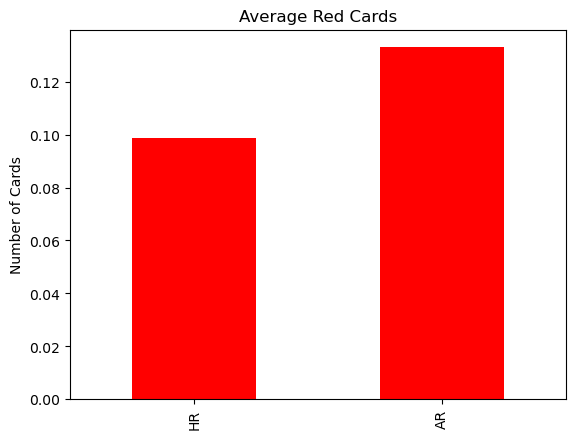

In [62]:
# Average Yellow Cards for Home and Away Teams
avg_yellows = merged_data[['HY', 'AY']].mean()
avg_yellows.plot(kind='bar')
plt.title('Average Yellow Cards')
plt.ylabel('Number of Cards')
plt.show()

# Average Red Cards for Home and Away Teams
avg_reds = merged_data[['HR', 'AR']].mean()
avg_reds.plot(kind='bar', color='red')
plt.title('Average Red Cards')
plt.ylabel('Number of Cards')
plt.show()


##  5.8. Correlation with Target Variable

In [63]:
# Correlation with 'FTR_numeric'
corr_with_target = corr_matrix['FTR_numeric'].sort_values(ascending=False)
corr_with_target.drop(labels=['FTR_numeric'], inplace=True)
corr_with_target


FTAG             0.441600
B365H            0.242338
AST              0.235198
AS               0.112011
HR               0.087284
HY               0.085424
HomeTeam_enc     0.077298
HF               0.018238
Month            0.009191
AC               0.005149
Hour            -0.002849
DayOfWeek_Num   -0.012123
Day             -0.024830
AY              -0.024831
Year            -0.025061
AF              -0.025082
B365D           -0.033647
HC              -0.039200
AR              -0.040876
AwayTeam_enc    -0.049815
HS              -0.088588
HST             -0.139079
B365A           -0.163458
FTHG            -0.230404
Name: FTR_numeric, dtype: float64